In [1]:
# This code creates an Xarray DataSet out of all relevant swot and grdc data (discharge measures, lon, lat, etc.) and then shows various plots for statistical analysis.
# The main goal is to compare the swot discharge data with in-situ values available in the grdc dataset.
# Author: Ève Castonguay, LIRA (CNRS)
# Creation date: 2026-05-29 [YYYY-MM-DD]
# Version 0.1: AAAA-MM-JJ

In [68]:
# Imports
from datetime import datetime
import os
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import glob 
import numpy as np
import netCDF4 as nc
from scipy.spatial import KDTree
from mpl_toolkits.basemap import Basemap
import cartopy.crs as ccrs
import math
from scipy import stats
import matplotlib.colors as mcolors
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import geopy.distance

## Part I - Extracting data

### 1. Making DataArrays for each variable (swot & grdc discharge, lon, lat, etc.)

In [3]:
## Section 0 : Setting some variables
continent_list = ['af', 'as', 'eu', 'na', 'sa', 'oc']
# Period during which SWOT has data (2023-03-29 to 2025-05-02)
swot_start = '2023-03-29'
swot_end = '2025-05-02'
# Empty dictionnaries for the DataArrays (there probably is a better way?)
runoff_darrays_g = {} # g : grdc
geox_darrays_g = {}
geoy_darrays_g = {}
area_darrays_g = {}
dschg_darrays_s = {} # s : swot
geox_darrays_s = {}
geoy_darrays_s = {}
id_darrays_s = {}
w_darrays_s = {}
area_darrays_s = {}

## Section 1 : Extracting the dataset from each SWOT continent file
# This code loads single continent file one at a time
dir_l4 = "/obs/ecastonguay/swot_data/L4_discharge/"
for i_continent in continent_list: # loop over continents
    file_suffix = "_sword_v16_SOS_results_unconstrained_20230502T204408_20250502T204408_20251219T163700.nc"
    single_file_name = dir_l4 + i_continent + file_suffix 
    data_l4 = nc.Dataset(single_file_name) # level 4 satellite data

    ## Section 2 : Extracting GRDC data
    # 2.1 Reading the data for the continent
    dir_grdc_prefix = "/obs/ecastonguay/grdc_data/"
    file_nc = i_continent + ".nc"
    path_nc = os.path.join(dir_grdc_prefix,i_continent,file_nc)
    file_json = "stationbasins_" + i_continent + ".geojson"
    path_json = os.path.join(dir_grdc_prefix,i_continent,file_json)
    # open the netcdf grdc file
    data_grdc = xr.open_dataset(path_nc, engine="netcdf4") # <xarray.Dataset>

    # 2.2 Putting all GRDC data in individual DataArrays (https://docs.xarray.dev/en/stable/generated/xarray.DataArray.html) 
    # filter for the period during which SWOT has data (2023-03-29 to 2025-05-02)
    data_grdc_23_25 = data_grdc.sel(time=slice(swot_start,swot_end)) # DataSet. slice here includes the last day.
    # swap dimensions to have (id,time) instead of (time,id)
    data_grdc_23_25 = data_grdc_23_25.transpose()
    # 2.2.1 runoff
    runoff_darray_23_25_g = data_grdc_23_25['runoff_mean'] # DataArray  
    # 2.2.2 X coordinates in DataArray
    geox_darray_g = data_grdc_23_25.geo_x # or ['geo'] # DataArray 
    # 2.2.3 Y coordinates in DataArray
    geoy_darray_g = data_grdc_23_25.geo_y 
    # 2.2.4 Area in DataArray
    area_darray_g = data_grdc_23_25.area

    # 2.3 Get a list of the stations_id of GRDC (id & time are the coordinates of the DataSet)
    list_station_id = runoff_darray_23_25_g["id"].values # [tested]  

    ## Section X : Extracting SWORD data
    # 3.1 Reading the file
    dir_swr = "/obs/ecastonguay/sword_data/netcdf_v16" # sword v16
    file_swr = i_continent + "_sword_v16.nc"
    path_swr = os.path.join(dir_swr,file_swr)
    data_swr = nc.Dataset(path_swr) # open the netcdf file
    # 3.2 List of reaches id
    r_list_swr = data_swr["reaches"]["reach_id"][:]

    ## Section 3 : Empty ndarrays for the data 
    station_pos = 0
    time_dim = pd.date_range(start=swot_start, end=swot_end, freq='D') # 766. ndarray-like of datetime64 data. dtype='datetime64[us].
    time_dim_len = len(time_dim)

    # 3.1 SWOT Discharge
    dschg_ndarray = np.full((len(list_station_id), time_dim_len), np.nan, dtype=np.float64) # dim (id, time)
    # 3.2 SWOT Lon
    x_ndarray = np.full((len(list_station_id)), np.nan, dtype=np.float64) # dim (id)
    # 3.3 SWOT Lat
    y_ndarray = np.full((len(list_station_id)), np.nan, dtype=np.float64) # dim (id)
    # 3.4 SWOT Reach id
    r_id_ndarray = np.full((len(list_station_id)), np.nan, dtype=np.float64) # dim (id)
    # 3.5 SWORD width
    w_ndarray = np.full((len(list_station_id)), np.nan, dtype=np.float64) # dim (id)
    # 3.6 SWORD area
    facc_ndarray = np.full((len(list_station_id)), np.nan, dtype=np.float64) # dim (id)

    ## Section 4 : Loop for reading all the GRDC stations of the continent and associating them with a reach
    n_10nn = 0 # number of reaches that are further than the 10th nearest neighboor
    n_not_found_swr = 0 # number of reaches that weren't found in the sword database
    for station_id in list_station_id:
        
        # 4.1 Finding the target (lon,lat) and the list of coordinates from SWOT
        # get grdc (lat,lon) target coordinates (gauge)
        x_found_station = geox_darray_g.sel(id=station_id).values
        y_found_station = geoy_darray_g.sel(id=station_id).values # [tested]
        # list of reaches in the continent-level swot data 
        reach_group = data_l4.groups['reaches']
        x_coordinates_values = reach_group['x'][:] # all x coordinates in swot/l4 data for the na continent
        y_coordinates_values = reach_group['y'][:]
        
        # 4.2 Finding a match between the GRDC gauge and the SWOT data at reach level
        # K-D tree to search nearest neighbor (looking for the reach with the closest coordinates to the station) (consensus_q only available at reach-level)
        stacked_xy = np.vstack((x_coordinates_values,y_coordinates_values)).T
        k_neighbors = 4
        distance_list, index_list = KDTree(stacked_xy).query([x_found_station, y_found_station],k=k_neighbors) # we take the k nearest neighboors so that if the nearest reach doesn't contain swot data, we look at the second nearest, ...
        ii = 0
        no_r_found = False
        while ii < k_neighbors:
            distance = distance_list[ii]
            index = index_list[ii] # index of the reach we will be associating with the station
            
            # 4.3 Checking if the selected nearest reach contains data; if not, will move on to the next nearest reach
            discharge_data_check = data_l4.groups["consensus"]['consensus_q'][index] # [tested]  <class 'numpy.ndarray'>
            mask_fill_values = (discharge_data_check != data_l4.groups["consensus"]['consensus_q'].missing_value) # [tested]
            consensus_q_flt = discharge_data_check[mask_fill_values] # [tested] for a given index, is all discharge data missing value?
            if consensus_q_flt.size == 0:
                if ii == (k_neighbors-1):
                    # print(f"Warning: [4.2] The closest reach to station {station_id} that contains data is further than the 10th nearest neighboor.")
                    n_10nn += 1
                    no_r_found = True
                ii += 1
                # print("Warning: [4.3] The closest reach doesn't contain valid data. Moving on to the next closest reach.")
                continue
            #if (distance > 4):      # even if the closest reach is far, KDTree will still find a match. therefore we need to make sure the distance found isn't too big
                                    # for reference, a 5,4 km distance between reach and gauge equals to a distance = 0.0557
                                    # ADJUST maximum distance
                #print(f"Warning: [4.3] The nearest reach associated with the station {station_id} is quite far from it's location. This might have an impact on the quality of the comparison.")
            # selected reach's index
            sel_r_index = index
            break # while ii < k_neighbors:
        """if (station_id==3103010):
            print(k_neighbors, f"for station {3103010}")"""
        if no_r_found:
            station_pos += 1 # end of the (for station_id in list_station_id:) loop
            continue # moving on to the next station, there was no reach found for this station_id. data will stay NaN.
        else: 

            ## Section 5 : Extracting relevant data and filtering out the fill values
            # SWOT discharge data is already filtered: consensus_q_flt
            # 5.1 SWOT time data
            time_data = data_l4.groups["consensus"]['time_int'][sel_r_index]
            time_flt = time_data[mask_fill_values]
            assert discharge_data_check.shape == time_data.shape # raises assertion error if not true
            assert consensus_q_flt.shape == time_flt.shape # raises assertion error if not true
            # converting time from int to datetime
            epoch = np.datetime64('2000-01-01')
            datetime_flt = epoch + time_flt.astype('timedelta64[s]')
            
            # 5.2 SWOT coordinates
            sel_r_x = data_l4.groups["reaches"]['x'][sel_r_index]
            sel_r_y = data_l4.groups["reaches"]['y'][sel_r_index]
            
            # 5.3 SWOT reach's id 
            sel_r_id = data_l4.groups['reaches']['reach_id'][sel_r_index]

            # 5.4 SWORD width
            r_index_swr = np.where(r_list_swr==sel_r_id)[0] # position of the reach in the SWORD database

            ## Section 6 : Use of .get_indexer to fill the empty ndarrays with data 
            # 6.1 Put hours,min,sec to 00:00:00 to ignore time and only keep date
            datetime_norm = pd.to_datetime(datetime_flt).normalize()
            ndarray_swot_index = time_dim.get_indexer(datetime_norm) # indice of everywhere where the day corresponds
            if -1 in ndarray_swot_index:
                print("Error: [6.1] Not all dates from the SWOT data were found in the time_dim vector (.get_indexer method)") 
            
            # 6.2 SWOT discharge
            dschg_ndarray[station_pos,ndarray_swot_index] = consensus_q_flt # [tested] where there is data the space will be filled, otherwise stays NaN
            
            # 6.3 SWOT coordinates
            x_ndarray[station_pos] = sel_r_x
            y_ndarray[station_pos] = sel_r_y
            
            # 6.4 SWOT reach id
            r_id_ndarray[station_pos] = sel_r_id

            # 6.5 SWORD width
            if r_index_swr[0].size != 0: # if the reach_id is found in the sword database
                w_ndarray[station_pos] = data_swr["reaches"]["width"][r_index_swr]
                facc_ndarray[station_pos] = data_swr["reaches"]["facc"][r_index_swr]
            else:
                n_not_found_swr += 1

        # end of the (for station_id in list_station_id:) loop
        station_pos += 1

    assert station_pos == len(list_station_id) # at the end of the station loop, these should be equal

    print(f"Number of reaches further than the {k_neighbors}th nearest neighboor: {n_10nn} for the {i_continent} continent.")
    print(f"Number of reaches that weren't found in the SWORD database: {n_not_found_swr} for the {i_continent} continent.")


    ## Section 7 : Create DataArrays for SWOT/SWORD (ndarrays ordered by station_id)
    # 7.1 SWT Discharge
    dschg_darray_s = xr.DataArray(
        data=dschg_ndarray,
        dims=["id","time"], # name of the dimensions
        coords=dict(
            id=list_station_id,
            time=time_dim,
        ),
        attrs=dict(
            description="Consensus_q from SWOT",
            units="m3/s",
        ),
        name="swot discharge"
    )

    # 7.2 SWT Coordinates
    if len(x_ndarray) != len(y_ndarray):
        print(f"Error: [7.2] The x and y vector of all the selected reaches' coordinates doesn't match in size")
        #break # *** activate when continent loop is added!
    # x_y_ndarray = np.hstack((x_ndarray,y_ndarray)) # doesn't work for now
    # dataarrays
    geox_darray_s = xr.DataArray(
        data=x_ndarray,
        dims=["id"], # name of the dimensions
        coords=dict(
            id=list_station_id,
        ),
        attrs=dict(
            description="X coordinate of each selected reach in the SWOT data",
            units="degrees",
        ),
        name="swot x coordinate"
    )
    geoy_darray_s = xr.DataArray(
        data=y_ndarray,
        dims=["id"], # name of the dimensions
        coords=dict(
            id=list_station_id,
        ),
        attrs=dict(
            description="Y coordinate of each selected reach in the SWOT data",
            units="degrees",
        ),
        name="swot y coordinate"
    )
    
    # 7.3 SWT Reach ids
    id_darray_s = xr.DataArray(
        data=r_id_ndarray,
        dims=["id"], # name of the dimensions
        coords=dict(
            id=list_station_id,
        ),
        attrs=dict(
            description="Id's of the selected reaches in the SWOT data"
        ),
        name="swot reach ids"
    )

    # 7.4 SWR Width
    w_darray_s = xr.DataArray(
        data=w_ndarray,
        dims=["id"], # name of the dimensions
        coords=dict(
            id=list_station_id,
        ),
        attrs=dict(
            description="Average width for a SWOT reach (units: meters)."
        ),
        name="sword widths"
    )

    # 7.5 SWR area
    area_darray_s = xr.DataArray(
        data=facc_ndarray,
        dims=["id"], # name of the dimensions
        coords=dict(
            id=list_station_id,
        ),
        attrs=dict(
            description="Maximum flow accumulation value for a node or reach. Flow accumulation values are extracted from the MERIT Hydro dataset (Yamazaki et al., 2019) (units: square kilometers)."
        ),
        name="sword area" 
    )

    ## Section 8 : Make sure all GRDC DataArrays have time dim of 766 days (between 2023-03-29 & 2025-05-02)
    # 8.1 Validate size of time dimension and possible expand
    if len(data_grdc_23_25.time) != len(runoff_darray_23_25_g.time):
        print(f"Error: [8.1] Both arrays are assumed to match in size. Please verify the code.")
    if len(runoff_darray_23_25_g.time) != time_dim_len:
        runoff_darray_23_25_g = runoff_darray_23_25_g.reindex(time=time_dim) # asia doesn't -> fill the time between 2024 & 2025 with NaN
        print(f"[8.1] DataArray of continent {i_continent} was reindexed")
    # *** missing values seem to be nan [tested]

    ## Section 9 : Append continent DataArrays to list
    runoff_darrays_g[i_continent] = runoff_darray_23_25_g
    geox_darrays_g[i_continent] = geox_darray_g
    geoy_darrays_g[i_continent] = geoy_darray_g
    area_darrays_g[i_continent] = area_darray_g
    dschg_darrays_s[i_continent] = dschg_darray_s
    geox_darrays_s[i_continent] = geox_darray_s
    geoy_darrays_s[i_continent] = geoy_darray_s
    id_darrays_s[i_continent] = id_darray_s
    w_darrays_s[i_continent] = w_darray_s
    area_darrays_s[i_continent] = area_darray_s

# end of the (for i_continent in continent_list) loop 

## Section 10 : Concathenate continent DataArrays. These are individual DataArrays that contain values for all continents
# grdc
runoff_global_g = xr.concat(list(runoff_darrays_g.values()), dim='id') 
geox_global_g = xr.concat(list(geox_darrays_g.values()), dim='id')
geoy_global_g = xr.concat(list(geoy_darrays_g.values()), dim='id')
area_global_g = xr.concat(list(area_darrays_g.values()), dim='id')
# swot
dschg_global_s = xr.concat(list(dschg_darrays_s.values()), dim='id') 
geox_global_s = xr.concat(list(geox_darrays_s.values()), dim='id')
geoy_global_s = xr.concat(list(geoy_darrays_s.values()), dim='id')
id_global_s = xr.concat(list(id_darrays_s.values()), dim='id')
width_global_s = xr.concat(list(w_darrays_s.values()), dim='id')
area_global_s = xr.concat(list(area_darrays_s.values()), dim='id')

Number of reaches further than the 4th nearest neighboor: 91 for the af continent.
Number of reaches that weren't found in the SWORD database: 0 for the af continent.
Number of reaches further than the 4th nearest neighboor: 27 for the as continent.
Number of reaches that weren't found in the SWORD database: 0 for the as continent.
Number of reaches further than the 4th nearest neighboor: 979 for the eu continent.
Number of reaches that weren't found in the SWORD database: 0 for the eu continent.
Number of reaches further than the 4th nearest neighboor: 483 for the na continent.
Number of reaches that weren't found in the SWORD database: 0 for the na continent.
Number of reaches further than the 4th nearest neighboor: 96 for the sa continent.
Number of reaches that weren't found in the SWORD database: 0 for the sa continent.
Number of reaches further than the 4th nearest neighboor: 315 for the oc continent.
Number of reaches that weren't found in the SWORD database: 0 for the oc contin

### 2. Global DataSet containing all swot & grdc variables

In [67]:
# Create the DataSet and append all the variables (DataArrays) to it
dset_global = runoff_global_g.to_dataset(name='dschg_global_g')
dset_global['geox_global_g'] = geox_global_g
dset_global['geoy_global_g'] = geoy_global_g
dset_global['area_global_g'] = area_global_g
dset_global['dschg_global_s'] = dschg_global_s
dset_global['geox_global_s'] = geox_global_s
dset_global['geoy_global_s'] = geoy_global_s
dset_global['id_global_s'] = id_global_s
dset_global['width_global_s'] = width_global_s
dset_global['area_global_s'] = area_global_s

# Change the data type of the reaches id which is (int)
# dset_global["id_global_s"] = dset_global["id_global_s"].astype(int) # *** actually, this can't be done since a numpy array of type int cannot contain nans (they would be transformed in -9223372036854775808)

# Print
print(dset_global)

# Save to netcdf
dset_global.to_netcdf("/obs/ecastonguay/scripts/global_dset_v2.nc")

<xarray.Dataset> Size: 49MB
Dimensions:         (time: 766, id: 5286)
Coordinates:
  * time            (time) datetime64[us] 6kB 2023-03-29 ... 2025-05-02
  * id              (id) int64 42kB 1159100 1159103 1159110 ... 5870600 5870655
Data variables:
    dschg_global_g  (id, time) float32 16MB 449.0 433.0 424.6 ... 59.33 49.56
    geox_global_g   (id) float32 21kB 17.72 19.15 20.36 ... 171.9 171.7 172.4
    geoy_global_g   (id) float32 21kB -28.76 -28.96 -31.81 ... -41.83 -41.76
    area_global_g   (id) float32 21kB 8.665e+05 8.599e+05 ... 6.35e+03 1.41e+03
    dschg_global_s  (id, time) float64 32MB nan nan nan nan ... nan nan nan nan
    geox_global_s   (id) float64 42kB 17.76 19.14 19.48 ... 171.7 171.6 172.9
    geoy_global_s   (id) float64 42kB -28.75 -28.96 -32.13 ... -42.29 -41.83
    id_global_s     (id) float64 42kB 1.273e+10 1.273e+10 ... 5.72e+10 5.721e+10
    width_global_s  (id) float64 42kB 138.0 150.0 43.5 43.5 ... 96.5 125.0 124.5
    area_global_s   (id) float64 42kB 7

## Part II - Making plots

### 1. Comparison of in-situ with swot 

Distance between reach and station is 0.49 km
The closest reach's id: 23261000911
Station coordinates are (51.399749755859375,7.161034107208252)
Reach coordinates are (51.4015268406082,7.1546411956168265)


/tmp/ipykernel_33577/2535818450.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Figure of station 6335030 saved in /obs/ecastonguay/scripts/figures


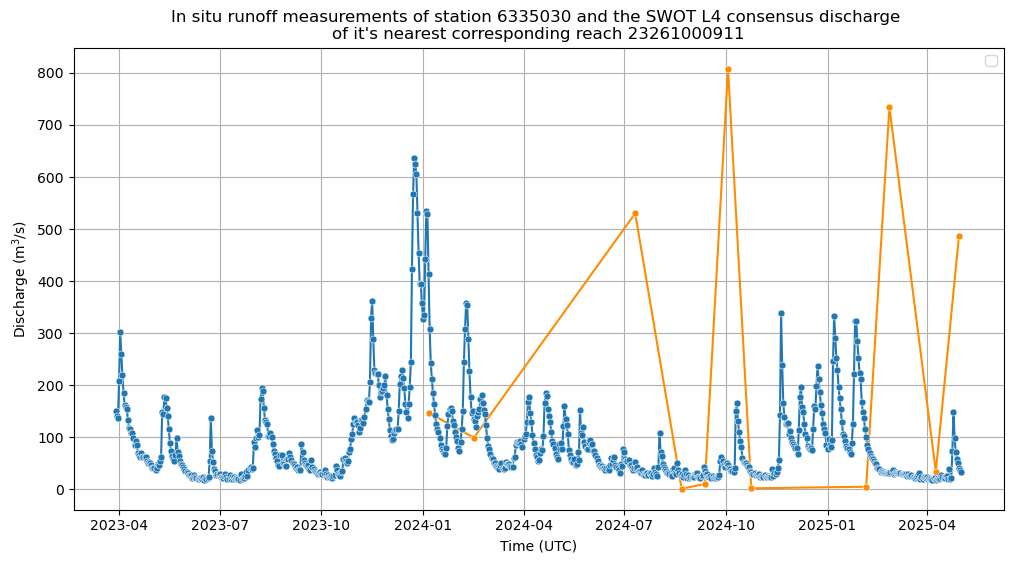

In [85]:
# Make sure the following variables are set correctly before running the code
list_stations_plot = [6335030] 
                                # SELECT stations in GRDC database to compare with SWOT data. Enter their stations id in int format.
                                # na
                                # 4127800 : article 3, fig 2a - Mississippi River near Baton Rouge, Louisiana, United States
                                # 4105850 : article 3, fig 2b - Kenai River near Soldotna, Alaska, United States
                                # eu
                                # 6139415 : article 3, fig 2c - Le Drac River near Grenoble, France
                                # sa
                                # 3626000 : amazonie, cours d'eau large de 3 km
                                # 3625000 : amazone
target_date_inf = "2023-07-01" # SELECT a time period for the plots
target_date_sup = "2024-09-21" # SWOT data : 2023-03-29 to 2025-05-02
use_target_date_filter = False # SELECT True if we want to use the above specified target dates, False if the goal is to display the discharge data for all time period available
save = True

# Making the plots          
for station_id in list_stations_plot:
    if station_id in dset_global['id'].values:
        # slicing data for the right id 
        dset_global_id_flt = dset_global.sel(id=station_id)
        closest_reach_id = dset_global_id_flt['id_global_s'].values
        if ~np.isnan(closest_reach_id):
            closest_reach_id = closest_reach_id.astype(int) 
            #else: closest_reach_id = "NaN"
        # compute distance between reach and station
        coords_s = (dset_global_id_flt["geoy_global_s"].values,dset_global_id_flt["geox_global_s"].values)
        coords_g = (dset_global_id_flt["geoy_global_g"].values,dset_global_id_flt["geox_global_g"].values)
        if (np.any(np.isnan(coords_s)) or np.any(np.isnan(coords_g))):
            print("Distance couldn't be computed due to missing (lat,lon) values")
        else:
            distance = geopy.distance.geodesic(coords_s, coords_g).km
            print(f"Distance between reach and station is {distance:.2f} km")
        # print (lat,lon)
        print(f"The closest reach's id: {closest_reach_id}")
        print(f"Station coordinates are ({dset_global_id_flt['geoy_global_g'].values},{dset_global_id_flt['geox_global_g'].values})")
        print(f"Reach coordinates are ({dset_global_id_flt['geoy_global_s'].values},{dset_global_id_flt['geox_global_s'].values})")
            
        plt.figure(figsize=(12, 6))
        plt.title(f"In situ runoff measurements of station {station_id} and the SWOT L4 consensus discharge \nof it's nearest corresponding reach {closest_reach_id}") 
        plt.xlabel('Time (UTC)') 
        plt.ylabel(r'Discharge (m$^3$/s)')
        plt.legend()
        plt.grid(True)
        
        if use_target_date_filter: 
            # slicing data for the right id & time period
            target_datetime_inf = np.datetime64(target_date_inf, 'D')
            target_datetime_sup = np.datetime64(target_date_sup, 'D')
            dset_global_date_flt = dset_global_id_flt.sel(time=slice(target_date_inf,target_date_sup)) 
            
            # filtering nans out of the swot data so that each dot in the graph is connected to another (the "orange problem")
            dschg_swt = dset_global_date_flt['dschg_global_s']
            or_mask = ~np.isnan(dschg_swt.values)

            plt.plot(dset_global_date_flt['time'].values[or_mask],dschg_swt.values[or_mask], marker='o', markersize=5, label='SWOT discharge', color='darkorange', markeredgecolor='white', markeredgewidth=0.4, linestyle='-')
            plt.plot(dset_global_date_flt['time'].values, dset_global_date_flt['dschg_global_g'].values, marker='o', markersize=5, label='In situ', color='tab:blue', alpha=1, markeredgecolor='white', markeredgewidth=0.4)

            fig_name = f'discharge_comparison_station{station_id}_r{closest_reach_id}_{target_date_inf}_{target_date_sup}.png'
        else:
            # filtering nans out of the swot data so that each dot in the graph is connected to another (the "orange problem")
            dschg_swt = dset_global_id_flt['dschg_global_s']
            or_mask = ~np.isnan(dschg_swt.values)

            plt.plot(dset_global_id_flt['time'].values[or_mask],dschg_swt.values[or_mask], marker='o', markersize=5, label='SWOT discharge', color='darkorange', markeredgecolor='white', markeredgewidth=0.4, linestyle='-')
            plt.plot(dset_global_id_flt['time'].values, dset_global_id_flt['dschg_global_g'].values, marker='o', markersize=5, label='In situ', color='tab:blue', alpha=1, markeredgecolor='white', markeredgewidth=0.4)

            fig_name = f'nse_median_{station_id}_r{closest_reach_id}.png' #f'discharge_comparison_station{station_id}_r{closest_reach_id}.png'
        
        if save:
            plt.savefig(f'/obs/ecastonguay/scripts/figures/{fig_name}', dpi=400, bbox_inches='tight')
            print(f"Figure of station {station_id} saved in /obs/ecastonguay/scripts/figures") # *** currently no error message if one of the station required to be plotted isn't in the GRDC data -> print(f"There is no correspondence in the GRDC in situ files for station id {station_id}")
        plt.show()  
    else:
        print(f'Error: the station {station_id} is not in the list of station ids from the GRDC data')


### 2.1 Maximum discharge per reach for swot

/tmp/ipykernel_33577/1339379520.py:5: RuntimeWarning: All-NaN slice encountered
  q_max = np.nanmax(dset_global['dschg_global_s'].values, axis=1) # value will be nan if no data


Figure saved in /obs/ecastonguay/scripts/figures


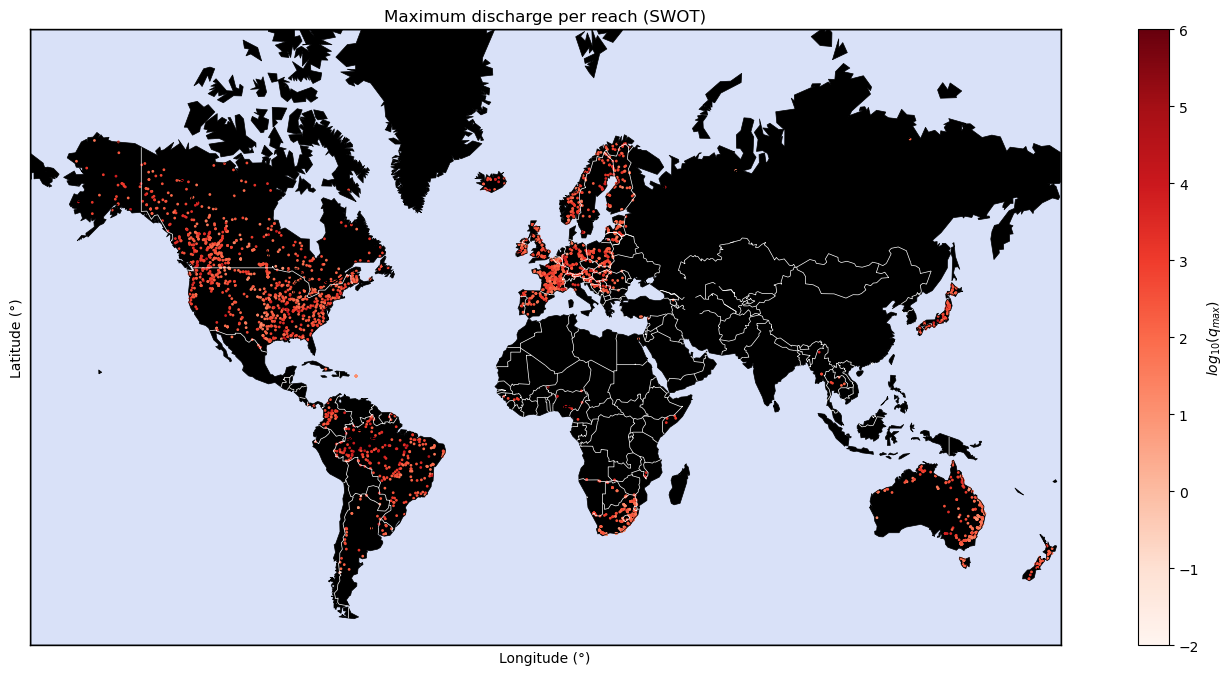

In [6]:
# Tutorial https://www.tutorialspoint.com/matplotlib/matplotlib_basemap.htm
# Colormaps https://matplotlib.org/stable/users/explain/colors/colormaps.html

# Compute maximum discharges (ignoring nans)
q_max = np.nanmax(dset_global['dschg_global_s'].values, axis=1) # value will be nan if no data

# Retrieve (lat,lon) of reaches (not stations)
x_s = dset_global['geox_global_s'].values
y_s = dset_global['geoy_global_s'].values

# Determine the 'view' of the world map
plt.figure(figsize=(20, 8))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.5)
map.drawcountries(color='w',linewidth=0.5)
map.drawmapboundary(fill_color=ocean_color)
map.fillcontinents(color='black', lake_color='black')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(x_s, y_s)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=np.log10(q_max), cmap='Reds', marker='o', alpha=1, s=1, vmin=-2,vmax=6) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label=r'$log_{10}(q_{max})$')
plt.title("Maximum discharge per reach (SWOT)") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'max_dschg_s_world.png'
plt.savefig(f'/obs/ecastonguay/scripts/figures/{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()


### 2.2 Minimum discharge per reach for swot

/tmp/ipykernel_33577/2877181335.py:5: RuntimeWarning: All-NaN slice encountered
  q_min = np.nanmin(dset_global['dschg_global_s'].values, axis=1) # value will be nan if no data


Figure saved in /obs/ecastonguay/scripts/figures


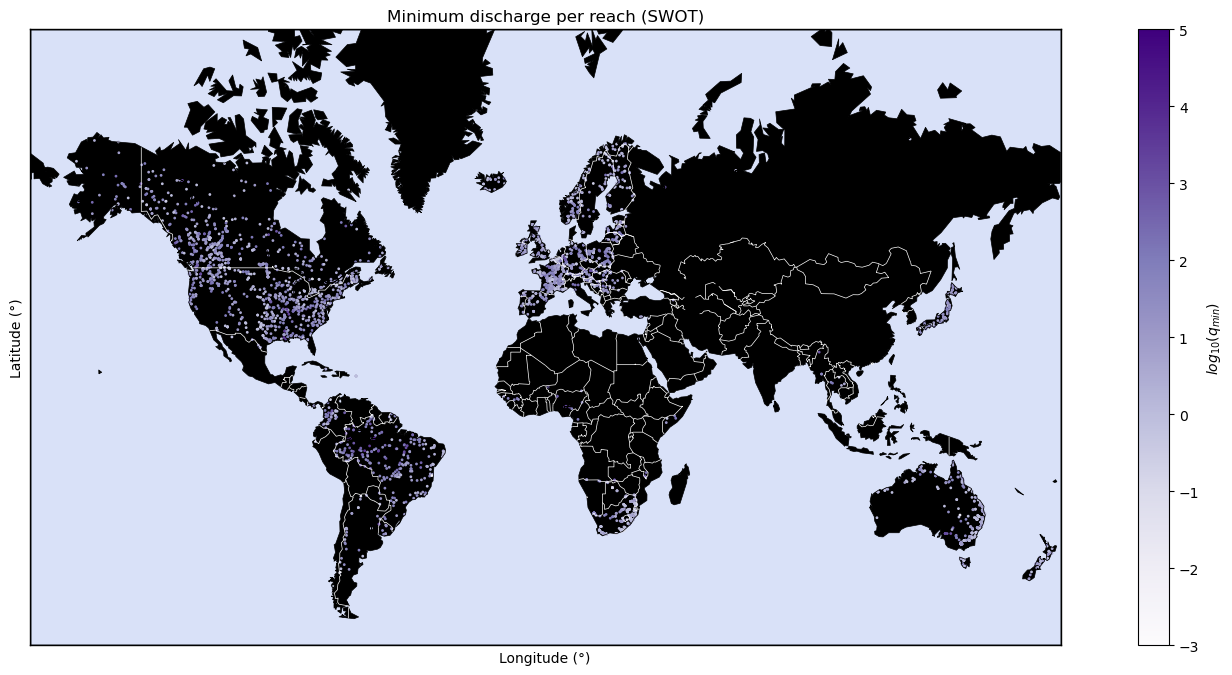

In [7]:
# Tutorial https://www.tutorialspoint.com/matplotlib/matplotlib_basemap.htm
# Colormaps https://matplotlib.org/stable/users/explain/colors/colormaps.html

# Compute maximum discharges (ignoring nans)
q_min = np.nanmin(dset_global['dschg_global_s'].values, axis=1) # value will be nan if no data

# Retrieve (lat,lon) of reaches (not stations)
x_s = dset_global['geox_global_s'].values
y_s = dset_global['geoy_global_s'].values

# Determine the 'view' of the world map
plt.figure(figsize=(20, 8))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.5)
map.drawcountries(color='w',linewidth=0.5)
map.drawmapboundary(fill_color=ocean_color)
map.fillcontinents(color='black', lake_color='black')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(x_s, y_s)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=np.log10(q_min), cmap='Purples', marker='o', alpha=1, s=1, vmin=-3,vmax=5) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label=r'$log_{10}(q_{min})$')
plt.title("Minimum discharge per reach (SWOT)") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'min_dschg_s_world.png'
plt.savefig(f'/obs/ecastonguay/scripts/figures/{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()

### 2.3 Maximum discharge per station for grdc

/tmp/ipykernel_33577/286157179.py:5: RuntimeWarning: All-NaN slice encountered
  r_max = np.nanmax(dset_global['runoff_global_g'].values, axis=1) # value will be nan if no data
/tmp/ipykernel_33577/286157179.py:32: RuntimeWarning: divide by zero encountered in log10
  mymap = map.scatter(x, y, c=np.log10(r_max), cmap='Reds', marker='o', alpha=1, s=1, vmin=-2,vmax=6) # s is markersize, [vmin=0,vmax=5000]


Figure saved in /obs/ecastonguay/scripts/figures


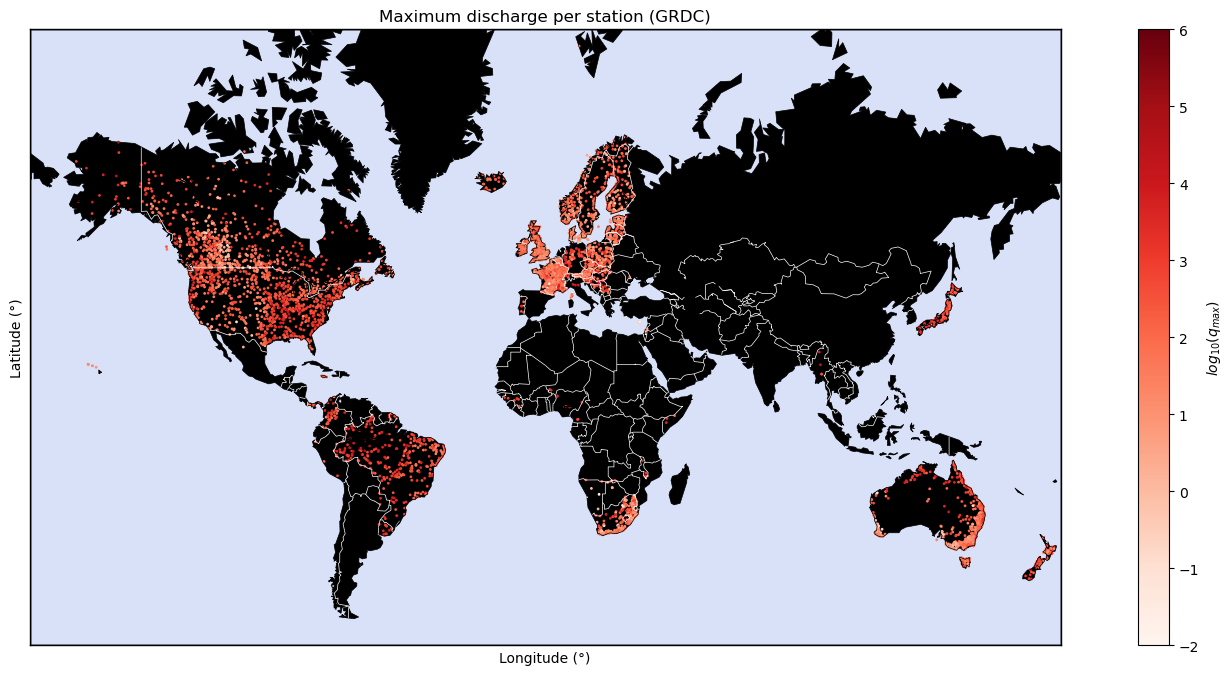

In [ ]:
# Tutorial https://www.tutorialspoint.com/matplotlib/matplotlib_basemap.htm
# Colormaps https://matplotlib.org/stable/users/explain/colors/colormaps.html

# Compute maximum discharges (ignoring nans)
r_max = np.nanmax(dset_global['dschg_global_g'].values, axis=1) # value will be nan if no data

# Retrieve (lat,lon) of stations
x_s = dset_global['geox_global_g'].values
y_s = dset_global['geoy_global_g'].values

# Determine the 'view' of the world map
plt.figure(figsize=(20, 8))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.5)
map.drawcountries(color='w',linewidth=0.5)
map.drawmapboundary(fill_color=ocean_color)
map.fillcontinents(color='black', lake_color='black')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(x_s, y_s)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=np.log10(r_max), cmap='Reds', marker='o', alpha=1, s=1, vmin=-2,vmax=6) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label=r'$log_{10}(q_{max})$')
plt.title("Maximum discharge per station (GRDC)") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'max_dschg_g_world.png'
plt.savefig(f'/obs/ecastonguay/scripts/figures/{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()


### 2.4 Minimum discharge per station for grdc

/tmp/ipykernel_33577/3488889315.py:5: RuntimeWarning: All-NaN slice encountered
  r_min = np.nanmin(dset_global['runoff_global_g'].values, axis=1) # value will be nan if no data
/tmp/ipykernel_33577/3488889315.py:32: RuntimeWarning: divide by zero encountered in log10
  mymap = map.scatter(x, y, c=np.log10(r_min), cmap='Purples', marker='o', alpha=1, s=1, vmin=-3,vmax=5) # s is markersize, [vmin=0,vmax=5000]


Figure saved in /obs/ecastonguay/scripts/figures


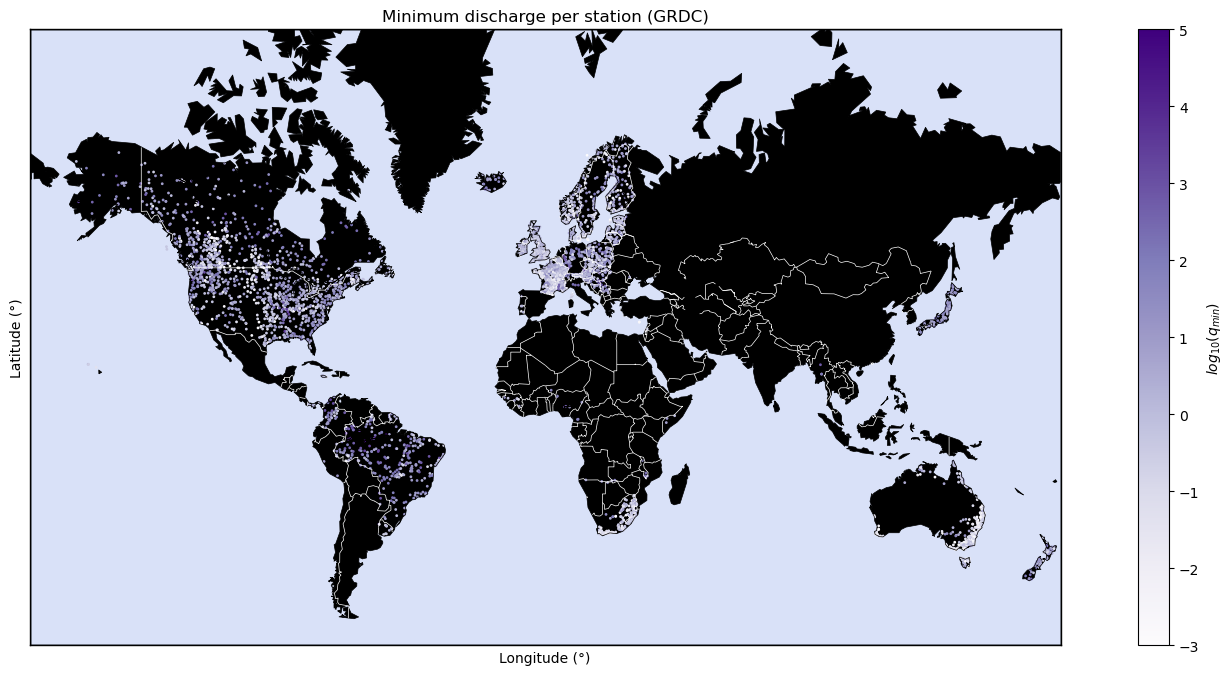

In [ ]:
# Tutorial https://www.tutorialspoint.com/matplotlib/matplotlib_basemap.htm
# Colormaps https://matplotlib.org/stable/users/explain/colors/colormaps.html

# Compute maximum discharges (ignoring nans)
r_min = np.nanmin(dset_global['dschg_global_g'].values, axis=1) # value will be nan if no data

# Retrieve (lat,lon) of stations
x_s = dset_global['geox_global_g'].values
y_s = dset_global['geoy_global_g'].values

# Determine the 'view' of the world map
plt.figure(figsize=(20, 8))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.5)
map.drawcountries(color='w',linewidth=0.5)
map.drawmapboundary(fill_color=ocean_color)
map.fillcontinents(color='black', lake_color='black')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(x_s, y_s)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=np.log10(r_min), cmap='Purples', marker='o', alpha=1, s=1, vmin=-3,vmax=5) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label=r'$log_{10}(q_{min})$')
plt.title("Minimum discharge per station (GRDC)") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'min_dschg_g_world.png'
plt.savefig(f'/obs/ecastonguay/scripts/figures/{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()


### **3. Selecting stations with sufficient swot-grdc temporal overlap**

In [ ]:
## Swot is ~21 days & grdc is ~daily. Both don't have data at the same time.
## Creating DataArrays containing dschg only when both have it.

# Count the number of days for which there are swot & grdc mesures, per station
mask_coincide = dset_global.dschg_global_g.notnull() & dset_global.dschg_global_s.notnull() # Array of True/False. True where there are both swot & grdc data
n_coincide = mask_coincide.sum(dim="time") # sum of Trues per station (5241,) # [tested]

# Compute the mean
mean_coincide = n_coincide.where(n_coincide != 0).mean() # 40.77 across all continent, ignoring zeros (WHEN there is a corresp., the avg number of time is ...) [tested]
mean_coincide_null = np.nanmean(n_coincide) # mean of 29.88 across all continents, including zeros [tested]

# Select stations where there are Co or more corresp.
co = 8 # number of correspondences
ids_co = n_coincide.id.where(n_coincide >= co, drop=True) # get the list of station id where error will be computed [tested] https://docs.xarray.dev/en/stable/generated/xarray.where.html
q_co_g = dset_global.sel(id=ids_co)["dschg_global_g"]
q_co_s = dset_global.sel(id=ids_co)["dschg_global_s"]
mask_coincide_co = mask_coincide.sel(id=ids_co) 

# DataArray of swot & grdc data only where both have data at the same time (rest is nan)
q_ol_g = q_co_g.where(mask_coincide_co) # ol : overlap
q_ol_s = q_co_s.where(mask_coincide_co)

# Retrieve (lat,lon) of stations
x_ol_s = dset_global.sel(id=ids_co)['geox_global_g'].values
y_ol_s = dset_global.sel(id=ids_co)['geoy_global_g'].values
x_ol_g = dset_global.sel(id=ids_co)['geox_global_s'].values
y_ol_g = dset_global.sel(id=ids_co)['geoy_global_s'].values

# Retrieve width of stations
w_ol_swr = dset_global.sel(id=ids_co)['width_global_s'].values

# Retrieve areas
area_ol_s = dset_global.sel(id=ids_co)['area_global_s'].values
area_ol_g = dset_global.sel(id=ids_co)['area_global_g'].values

# Retrieve ids
id_ol_s = dset_global.sel(id=ids_co)['id_global_s'].values
id_ol_g = dset_global.sel(id=ids_co).id.values


### 4. Swot's biais

Figure saved in /obs/ecastonguay/scripts/figures


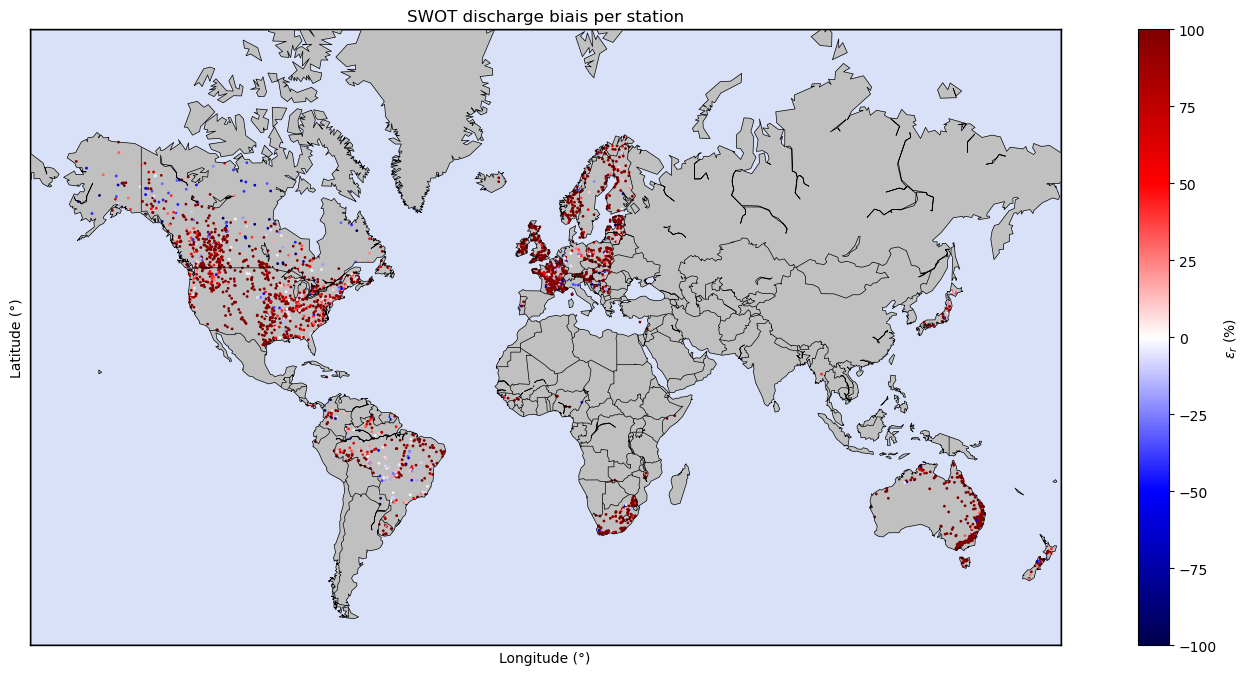

In [28]:
# Compute statistic
eps = 0.5 # to filter out the smaller discharges that would result in a value of inf (/0)
inf_mask = (q_ol_s >= eps) & (q_ol_g >= eps)
q_mask_g = q_ol_g.where(inf_mask) 
q_mask_s = q_ol_s.where(inf_mask) 
daily_err = (q_mask_s - q_mask_g) / q_mask_g # Nans will be ignored in the computations
mean_err = daily_err.mean(dim="time")*100

# Determine the 'view' of the world map
plt.figure(figsize=(20, 8))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.5)
map.drawcountries(color='k',linewidth=0.5)
map.drawmapboundary(fill_color=ocean_color)
map.fillcontinents(color='silver', lake_color='silver')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(x_ol_s, y_ol_s)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=mean_err, cmap='seismic', marker='o', alpha=1, s=1, vmin=-100,vmax=100) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label=r'$\varepsilon_r$ (%)')
plt.title("SWOT discharge biais per station") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'biais_world.png'
plt.savefig(f'/obs/ecastonguay/scripts/figures/{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()


### 5. Mean absolute error (MAE)

Figure saved in /obs/ecastonguay/scripts/figures


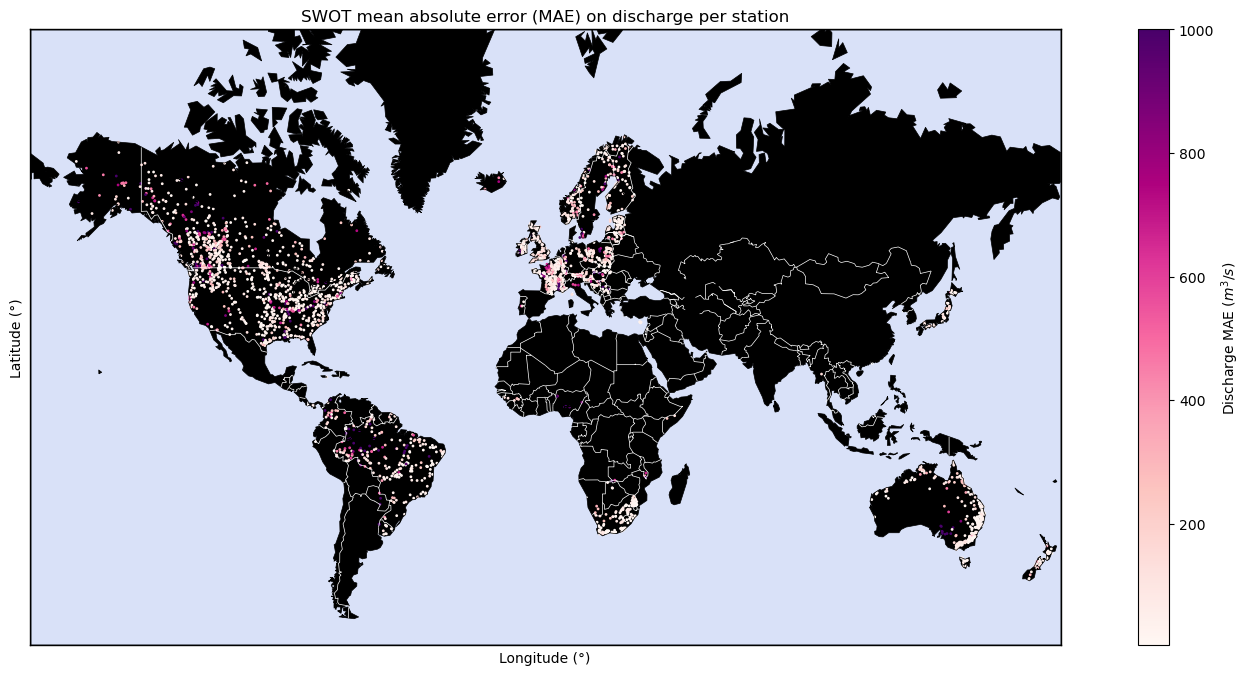

In [32]:
# Compute statistic
daily_err = np.absolute(q_ol_s-q_ol_g)
mean_err = daily_err.mean(dim="time")

# Determine the 'view' of the world map
plt.figure(figsize=(20, 8))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.5)
map.drawcountries(color='w',linewidth=0.5)
map.drawmapboundary(fill_color=ocean_color)
map.fillcontinents(color='black', lake_color='black')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(x_ol_s, y_ol_s)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=mean_err, cmap='RdPu', marker='o', alpha=1, s=1, vmax=1000) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label=r'Discharge MAE ($m^3/s$)')
plt.title("SWOT mean absolute error (MAE) on discharge per station") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'mae_world.png'
plt.savefig(f'/obs/ecastonguay/scripts/figures/{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()


### 6. PDF of the differences

Error: NaN detected.
Figure saved in /obs/ecastonguay/scripts/figures


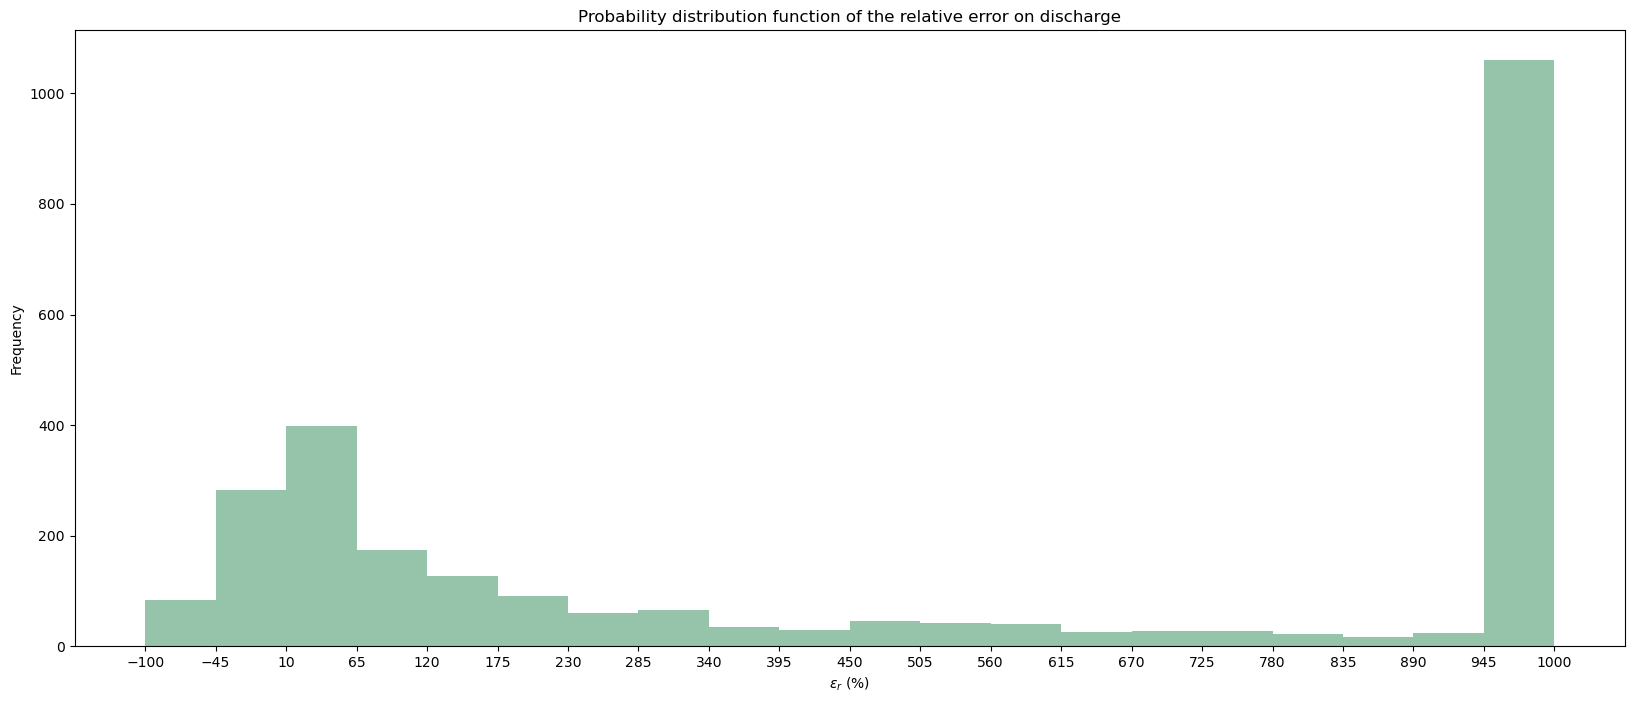

In [34]:
## For a given station, mean of the relative error.
## Clip the last bin: https://stackoverflow.com/questions/71818401/set-the-last-bin-of-histogram-to-a-range-to-include-all-large-values-seaborn-ma
## *** add a + to the last bin so that we know 

# Compute statistic
eps = 0.5 # to filter out the smaller discharges that would result in a value of inf (/0)
inf_mask = (q_ol_s >= eps) & (q_ol_g >= eps)
q_mask_g = q_ol_g.where(inf_mask) 
q_mask_s = q_ol_s.where(inf_mask) 
daily_err = (q_mask_s - q_mask_g) / q_mask_g # Nans will be ignored in the computations
mean_err = daily_err.mean(dim="time")*100
mean_arr = mean_err.values

if np.isnan(mean_arr).any():
    print("Error: NaN detected.")

# Clipping the very high values (including infinites) to a defined maximum
max_err = 1000
min_err = np.nanmin(mean_arr)
clip_sum = np.clip(mean_arr,min_err,max_err)

"""# Check the number of stations containing errors bigger than 100000
ids_co = sum_err.id.where(sum_err > 15000, drop=True)
max_sum = np.nanmax(sum_err)
min_sum = np.nanmin(sum_err)
print(min_sum,max_sum)
step = np.absolute(np.max(daily_err)-np.min(daily_err))/50
my_bins = np.arange(np.min(daily_err),np.max(daily_err),step)"""

# Plot
plt.figure(figsize=(20, 8))
n_bins = 20
step = (max_err-min_err)/n_bins
my_bins = np.arange(min_err,max_err+1,step)
plt.hist(clip_sum, bins=my_bins, color = 'seagreen', alpha=0.5)
#plt.title(f"In situ runoff measurements of station {station_id} and the SWOT L4 consensus discharge \nof it's nearest corresponding reach {closest_reach_id}") 
plt.xticks(my_bins)
plt.xlabel(r'$\varepsilon_r$ (%)') 
plt.ylabel('Frequency')
plt.title("Probability distribution function of the relative error on discharge") 

# Save
fig_name = f'pdf_v1.png' # SELECT file name
plt.savefig(f'/obs/ecastonguay/scripts/figures/{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures")
plt.show()


### 7. Seasonal amplitude

In [14]:
## Results to be analyzed with precaution; there is still very little data available for each season.

### 8. Temporal correlation

Figure saved in /obs/ecastonguay/scripts/figures


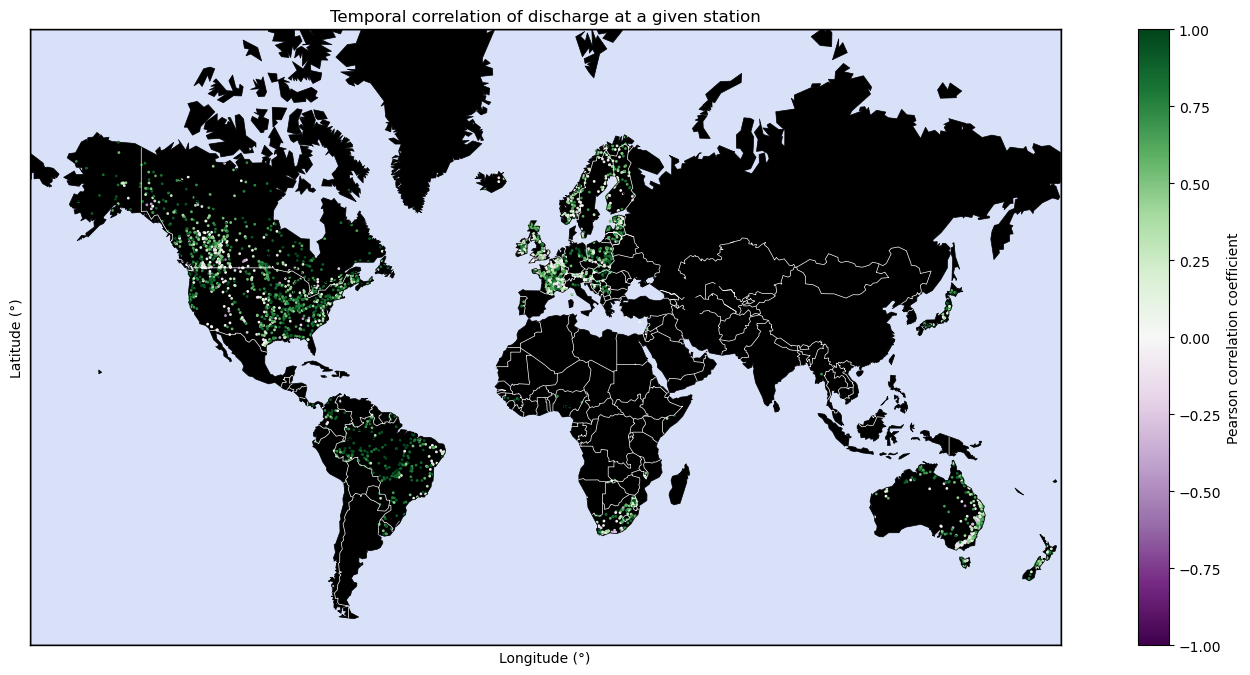

In [35]:
## If grdc discharge at a certain reach increases, does swot data do too?
## Computing Pearson corr. coeff. (linear correlation coefficient) for every station.
## https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html

# Measuring temp. corr. only when grdc & swot both have data at a certain time 
r_matrix = xr.corr(q_ol_s, q_ol_g, dim='time') # [tested]

# Determine the 'view' of the world map
plt.figure(figsize=(20, 8))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.5)
map.drawcountries(color='w',linewidth=0.5)
map.drawmapboundary(fill_color=ocean_color) # ocean color
map.fillcontinents(color='black', lake_color='black')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(x_ol_s, y_ol_s)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=r_matrix, cmap='PRGn', marker='o', alpha=1, s=1, vmin=-1,vmax=1) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label='Pearson correlation coefficient')
plt.title("Temporal correlation of discharge at a given station") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'temp_corr_world.png'
plt.savefig(f'/obs/ecastonguay/scripts/figures/{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()

### 9. a) Kling–Gupta Efficiency (KGE) coefficient

/obs/ecastonguay/miniconda3/envs/swot-env/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/obs/ecastonguay/miniconda3/envs/swot-env/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/tmp/ipykernel_33577/1261188996.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  alpha = np.std(sim) / np.std(obs)
/tmp/ipykernel_33577/1261188996.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  beta = np.mean(sim) / np.mean(obs)


Figure saved in /obs/ecastonguay/scripts/figures


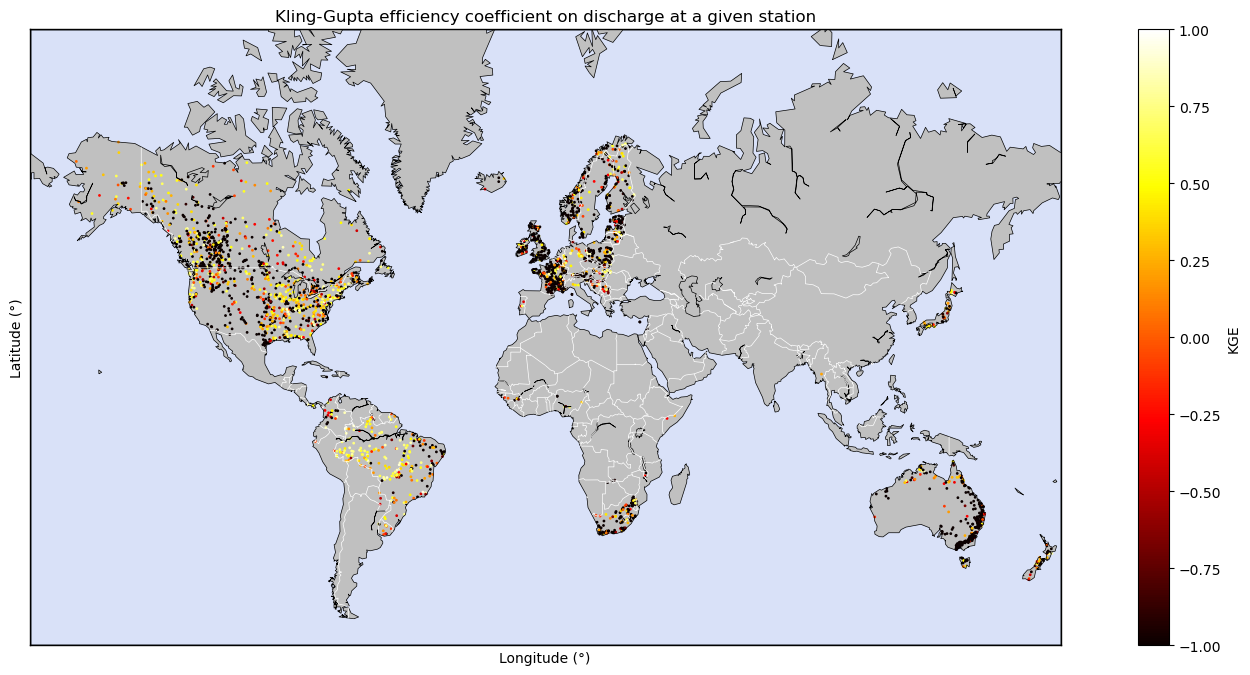

In [61]:
## KGE definition
def kge(sim, obs):
    sim = np.asarray(sim, dtype=float)
    obs = np.asarray(obs, dtype=float)

    mask = np.isfinite(sim) & np.isfinite(obs)
    sim = sim[mask]
    obs = obs[mask]

    r = np.corrcoef(sim, obs)[0, 1]     # this is a correlation matrix. has size (2,2) for the 2 variables that are put as rows and columns. 
                                        # diagonals should always equal 1 because a given variable is perfectly correlated with itself.
    alpha = np.std(sim) / np.std(obs)
    beta = np.mean(sim) / np.mean(obs)

    kge_value = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

    return kge_value #, r, alpha, beta

# Compute statistic
assert q_ol_g.shape == q_ol_s.shape

kge_matrix = np.array([ # q_ol_g.shape: (2776, 766)
    kge(q_ol_s[ii, :], q_ol_g[ii, :])
    for ii in range(q_ol_g.shape[0])
])

if kge_matrix.shape[0] != q_ol_g.shape[0] != q_ol_s.shape[0]:
    print("Error: Matrixes should have same number of rows. If the kge function deleted rows due to infinite values, adjust (lat,lon) accordingly.")
    
# Determine the 'view' of the world map
plt.figure(figsize=(20, 8))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.5)
map.drawcountries(color='w',linewidth=0.5)
map.drawmapboundary(fill_color=ocean_color) # ocean color
map.fillcontinents(color='silver', lake_color='silver')
#map.fillcontinents(color='black', lake_color='black')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(x_ol_s, y_ol_s)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=kge_matrix, cmap='hot', marker='o', alpha=1, s=1, vmin=-1,vmax=1) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label='KGE')
plt.title("Kling-Gupta efficiency coefficient on discharge at a given station") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'kge_world.png'
plt.savefig(f'/obs/ecastonguay/scripts/figures/{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()

### 9. b) 10 best KGE

In [17]:
# KGE
kge2 = np.where(np.isnan(kge_matrix), -np.inf, kge_matrix)

# Ids of the n best
n_best = 10
print("-> Stations having the best KGE (worst to best):")
ind_best = np.argpartition(kge2, -n_best)[-n_best:] 
ind_best_sorted = ind_best[np.argsort(kge2[ind_best])] # argpartition does not garantee to sort so we use argsort. sort goes from smallest to biggest value

# List of the 10 best
assert id_ol_g.shape == kge2.shape
kge_10_best = []
kge_10_best.append(id_ol_g[ind_best_sorted])
print(kge_10_best)

# Print
for b in range(len(ind_best_sorted)):
    print(f"Station id: {id_ol_g[ind_best_sorted][b]}. KGE value: {kge2[ind_best_sorted][b]}")

# Median of the distribution
median_da = np.nanmedian(kge_matrix) # using kge_matrix with nan values, not kge2 
median_id_g = id_ol_g[kge_matrix==median_da][0]
print("-> Median value")
print(f"Station id: {median_id_g}. KGE value: {median_da}")

## Results for n best:
# [6854101, 4127502, 3666500, 2589700, 4123202, 3649619, 4245950, 6122380, 3652870, 3649424]
## Results for median: 
# 3635451

-> Stations having the best KGE (worst to best):
[array([6854101, 4127502, 3666500, 2589700, 4123202, 3649619, 4245950,
       6122380, 3652870, 3649424])]
Station id: 6854101. KGE value: 0.8971538045926875
Station id: 4127502. KGE value: 0.8994265928476851
Station id: 3666500. KGE value: 0.8998520875464004
Station id: 2589700. KGE value: 0.9103514159415698
Station id: 4123202. KGE value: 0.9104326571160282
Station id: 3649619. KGE value: 0.9118606399113878
Station id: 4245950. KGE value: 0.9186411346943373
Station id: 6122380. KGE value: 0.9354016878482285
Station id: 3652870. KGE value: 0.942076961782238
Station id: 3649424. KGE value: 0.9598945860886638
-> Median value
Station id: 3635451. KGE value: -2.0876616322846777


### 10. Scatter plot function of discharge

/obs/ecastonguay/miniconda3/envs/swot-env/lib/python3.14/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: invalid value encountered in log10
  result_data = func(*input_data)


Figure saved in /obs/ecastonguay/scripts/figures


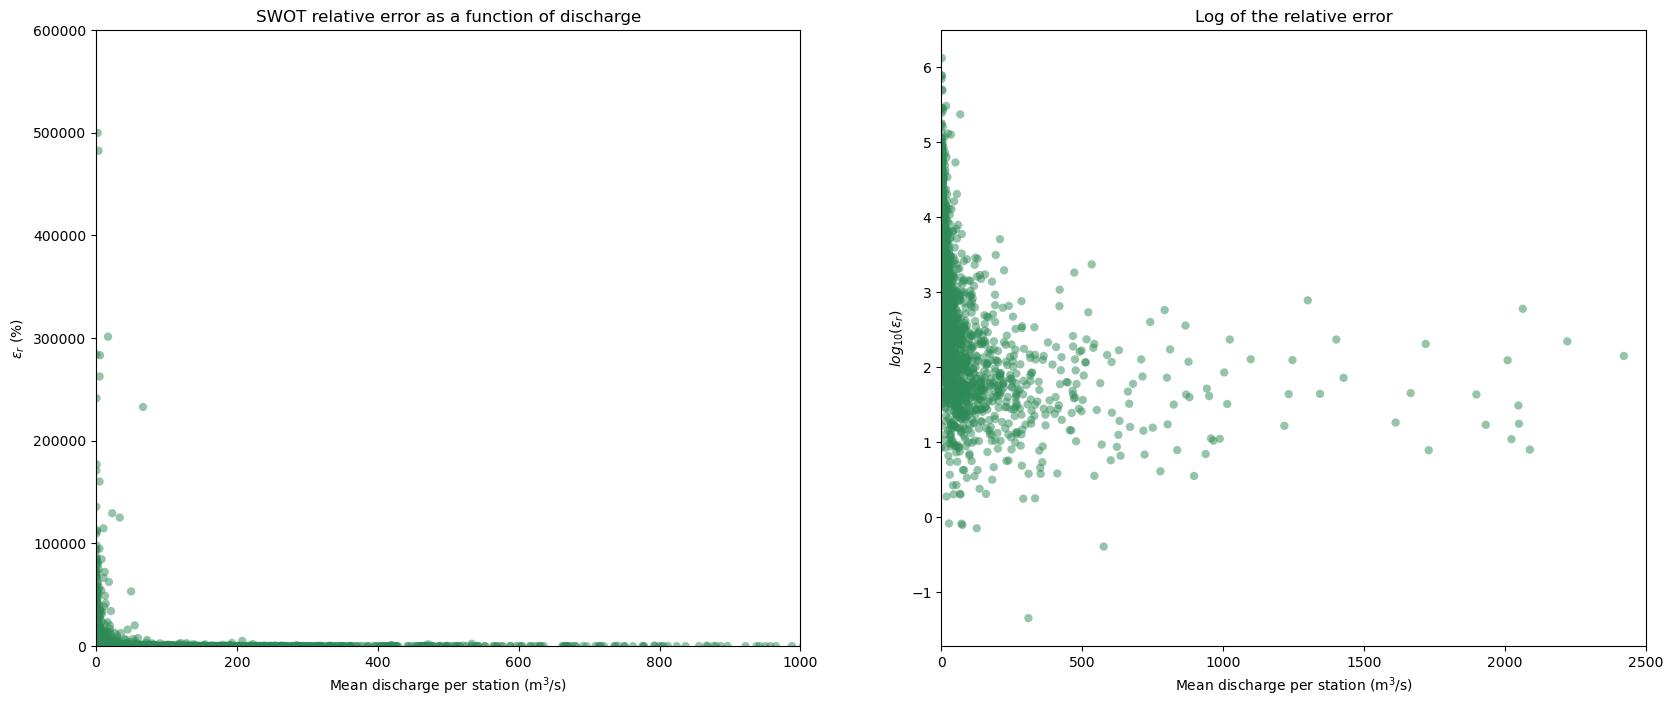

In [47]:
# Mean discharge of the river (y-axis) -> grdc data
daily_dschg = q_ol_g
mean_dschg = daily_dschg.mean(dim="time") # (2840,)

# River discharge min and max (y-axis limits)
max_dschg = np.max(mean_dschg) # 139024.55
min_dschg = np.min(mean_dschg) # 0

# Compute statistic
eps = 0.5 # to filter out the smaller discharges that would result in a value of inf (/0)
inf_mask = (q_ol_s >= eps) & (q_ol_g >= eps)
q_mask_g = q_ol_g.where(inf_mask) 
q_mask_s = q_ol_s.where(inf_mask) 
daily_err = (q_mask_s - q_mask_g) / q_mask_g # Nans will be ignored in the computations
mean_err = daily_err.mean(dim="time")*100
log_err = np.log10(mean_err) # (2840,)

# Scatter plot
fig, ax = plt.subplots(1,2,sharex=False, sharey=False, figsize=(20, 8))
# fig. full
ax[0].scatter(mean_dschg, mean_err, c='seagreen', alpha=0.5, edgecolors='none')
ax[0].set_xlim((0,1000)) # truncate 
ax[0].set_ylim((0,600000)) # truncate 
ax[0].set_title("SWOT relative error as a function of discharge") 
ax[0].set_xlabel(r'Mean discharge per station (m$^3$/s)')
ax[0].set_ylabel(r'$\varepsilon_r$ (%)')
# fig. truncated
ax[1].scatter(mean_dschg, log_err, c='seagreen', alpha=0.5, edgecolors='none')
ax[1].set_xlim((0,2500)) # truncate 
ax[1].set_title("Log of the relative error") 
ax[1].set_xlabel(r'Mean discharge per station (m$^3$/s)')
ax[1].set_ylabel(r'$log_{10}(\varepsilon_r)$')

# Save
fig_name = f'sct_dschg.png'
plt.savefig(f'/obs/ecastonguay/scripts/figures/{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()

### 11. Log of relative error vs. width

Figure saved in /obs/ecastonguay/scripts/figures


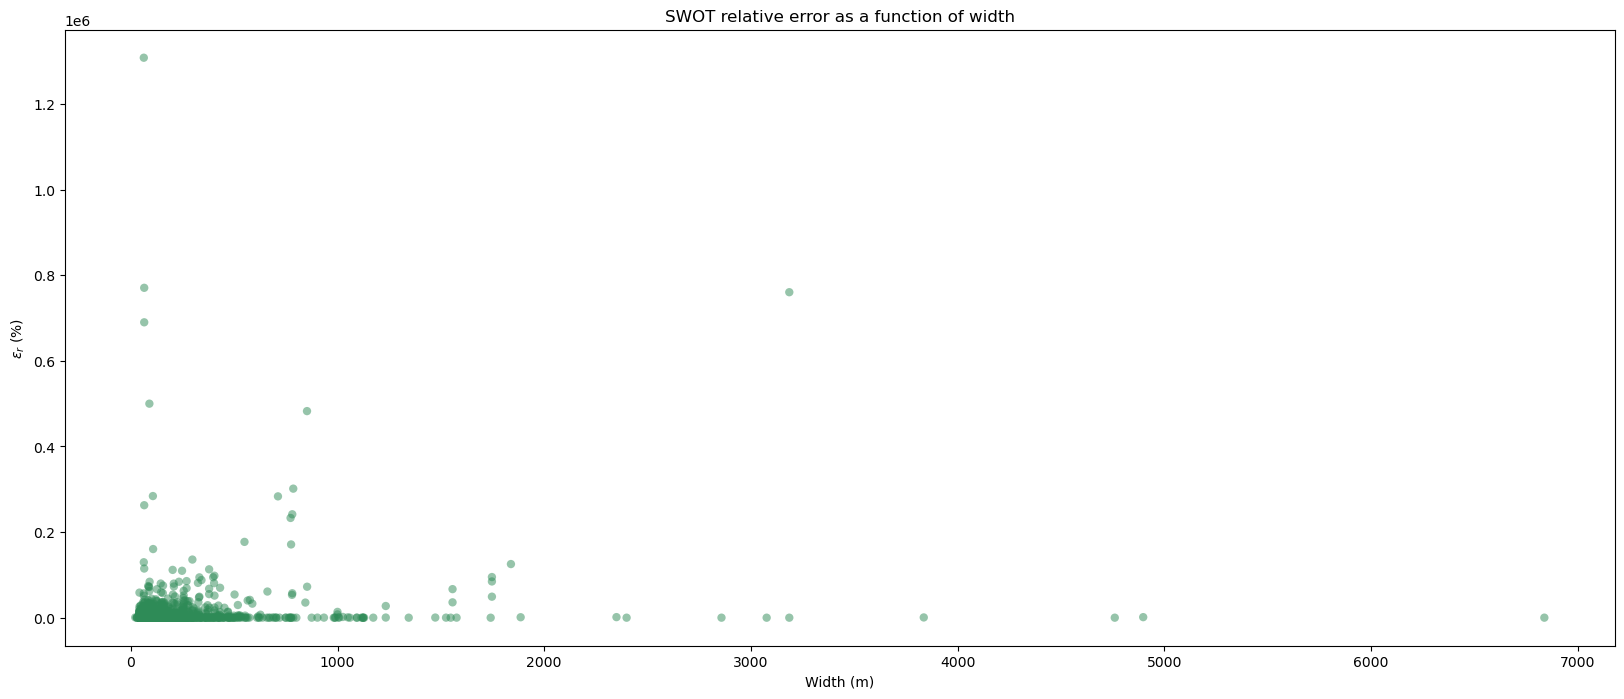

In [49]:
# Compute statistic
eps = 0.5 # to filter out the smaller discharges that would result in a value of inf (/0)
inf_mask = (q_ol_s >= eps) & (q_ol_g >= eps)
q_mask_g = q_ol_g.where(inf_mask) # else will be nan
q_mask_s = q_ol_s.where(inf_mask) 
daily_err = (q_mask_s - q_mask_g) / q_mask_g # Nans will be ignored in the computations
mean_err = daily_err.mean(dim="time")*100 # relative mean error for a given station

# Scatter plot
plt.figure(figsize=(20, 8))
plt.scatter(w_ol_swr, mean_err, c='seagreen', alpha=0.5, edgecolors='none')
#plt.ylim((0,1000))
plt.title("SWOT relative error as a function of width") 
plt.xlabel(r'Width (m)')
plt.ylabel(r'$\varepsilon_r$ (%)')

# Save
fig_name = f'sct_w.png'
plt.savefig(f'/obs/ecastonguay/scripts/figures/{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()

### 12. Annual amplitude

Figure saved in /obs/ecastonguay/scripts/figures


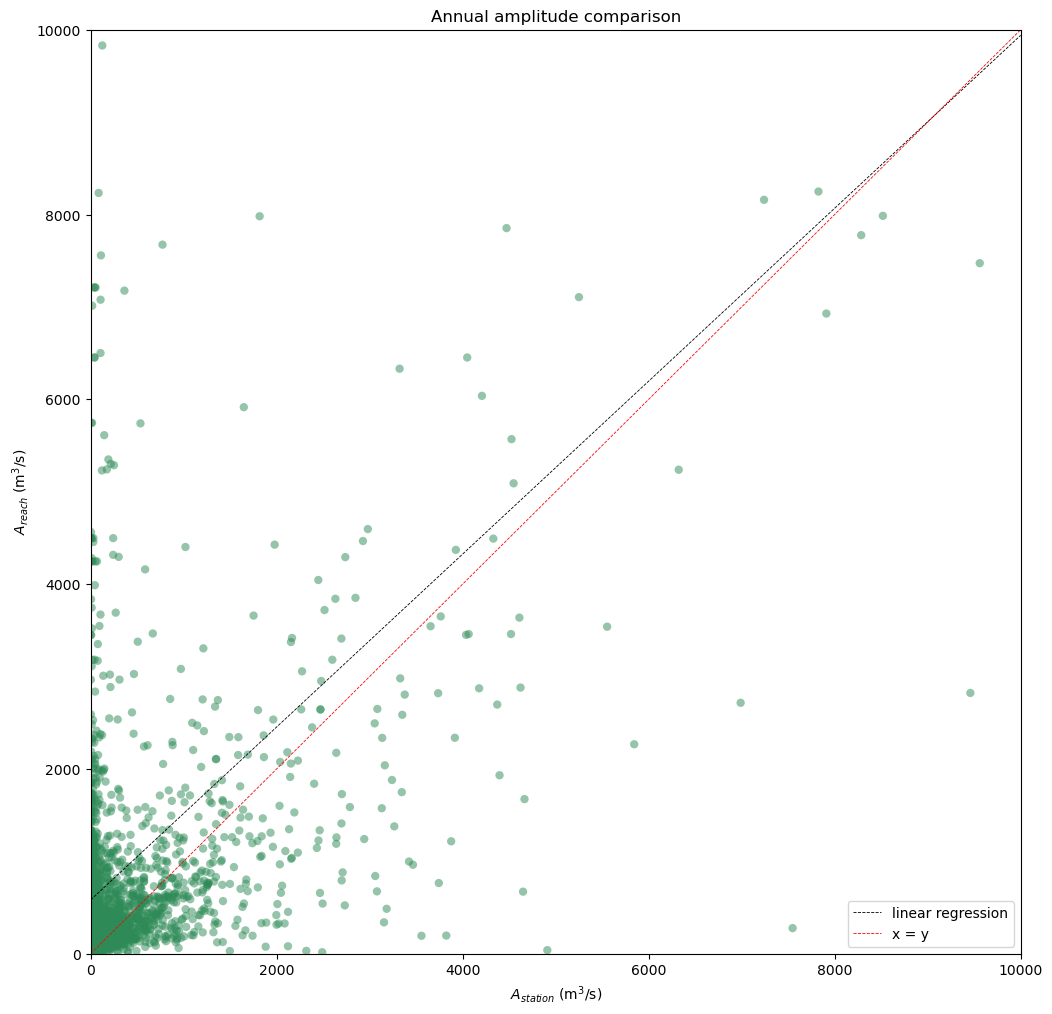

In [52]:
# SWOT amplitude
min_s = q_ol_s.min(dim="time",skipna=True)
max_s = q_ol_s.max(dim="time",skipna=True)
ampli_s = max_s-min_s

# GRDC amplitude
min_g = q_ol_g.min(dim="time",skipna=True)
max_g = q_ol_g.max(dim="time",skipna=True)
ampli_g = max_g-min_g

# Scatter plot
plt.figure(figsize=(12, 12))
plt.scatter(ampli_g, ampli_s, c='seagreen', alpha=0.5, edgecolors='none')

# Linear regression
a, b = np.polyfit(ampli_g, ampli_s, deg=1)
plt.axline(xy1=(0, b), slope=a, label=f'linear regression', color='k', linestyle='--', linewidth = 0.6)

# X = y slope
xy = np.arange(np.nanmax(ampli_g))
s, d = np.polyfit(xy, xy, deg=1)
plt.axline(xy1=(0, d), slope=s, label=f'x = y', color='r', linestyle='--', linewidth = 0.6)

# Titles
plt.ylim((0,10000))
plt.xlim((0,10000))
plt.title("Annual amplitude comparison") 
plt.legend()
plt.xlabel(r'$A_{station}$ (m$^3$/s)')
plt.ylabel(r'$A_{reach}$ (m$^3$/s)')

# Save
fig_name = f'ampli_year_4nn_a10000.png'
plt.savefig(f'/obs/ecastonguay/scripts/figures/{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()

### 13. a) Mean relative discharge difference vs. distance

/obs/ecastonguay/miniconda3/envs/swot-env/lib/python3.14/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: invalid value encountered in log10
  result_data = func(*input_data)


Figure saved in /obs/ecastonguay/scripts/figures


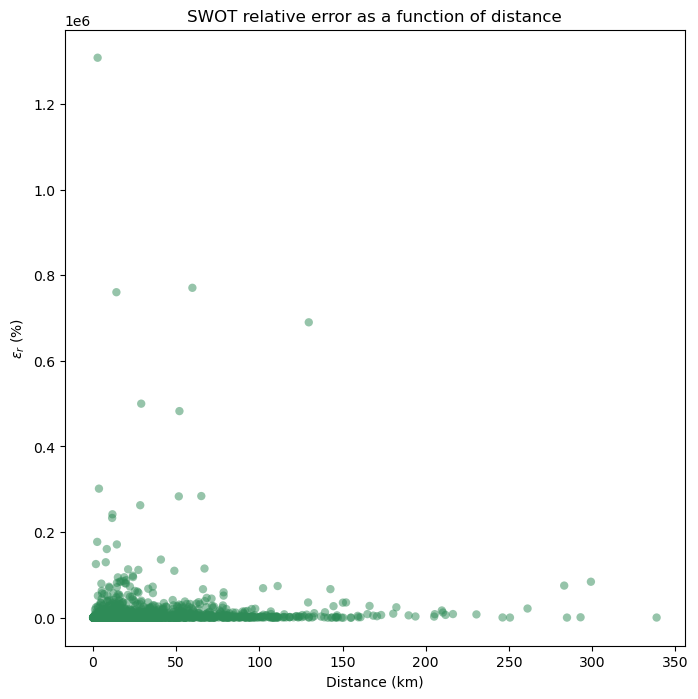

In [54]:
# Mean relative discharge difference for a reach
eps = 0.5 # to filter out the smaller discharges that would result in a value of inf (/0)
inf_mask = (q_ol_s >= eps) & (q_ol_g >= eps)
q_mask_g = q_ol_g.where(inf_mask) # else will be nan
q_mask_s = q_ol_s.where(inf_mask) 
daily_err = (q_mask_s - q_mask_g) / q_mask_g # Nans will be ignored in the computations
mean_diff_q = daily_err.mean(dim="time")*100 # relative mean error for a given station
log_err = np.log10(mean_diff_q) # (2840,)

"""# Distance between GRDC and SWT coordinates - method 1
R = 6371.0084 # mean radius of the earth, https://ssd.jpl.nasa.gov/planets/phys_par.html
latg = np.radians(y_ol_g) 
long = np.radians(x_ol_g)
lats = np.radians(y_ol_s)
lons = np.radians(x_ol_s)

dlon = lons - long
dlat = lats - latg

a = np.sin(dlat / 2)**2 + np.cos(latg) * np.cos(lats) * np.sin(dlon / 2)**2
c = 2 * np.atan2(np.sqrt(a), np.sqrt(1 - a))

distance2 = R * c """

# Distance between GRDC and SWT coordinates - method 2
distance = np.full(len(y_ol_s),np.nan, dtype=np.float64)
for jj in range (len(y_ol_s)):
    coords_s = (y_ol_s[jj], x_ol_s[jj])
    coords_g = (y_ol_g[jj], x_ol_g[jj])
    distance[jj] = geopy.distance.geodesic(coords_s, coords_g).km

# Scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(distance, mean_diff_q, c='seagreen', alpha=0.5, edgecolors='none')

# Titles
"""plt.ylim((-10000,10000))
plt.xlim((0,100))"""
plt.title("SWOT relative error as a function of distance") 
plt.xlabel(r'Distance (km)')
plt.ylabel(r'$\varepsilon_r$ (%)')

# Save
fig_name = f'dschg_vs_dist.png'
plt.savefig(f'/obs/ecastonguay/scripts/figures/{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()

### 14. Pdf of the distances (to decide on a k nearest neighboor) **(done on 10-nn)**

-> Percentage of reaches at less than 10km distance from the station: 48.60
Figure saved in /obs/ecastonguay/scripts/figures


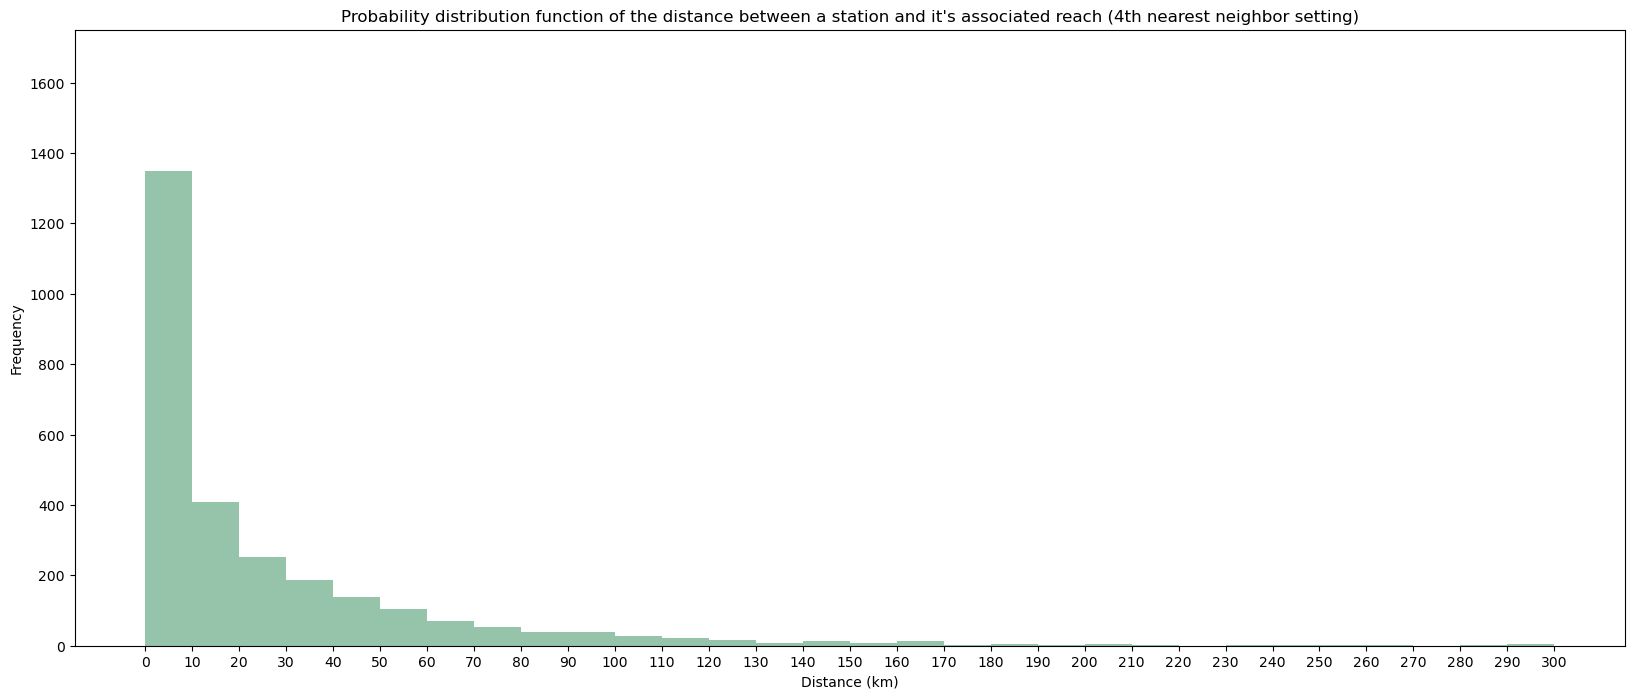

In [55]:
## Pdf of the number of stations per distance interval
# Distance between GRDC and SWT coordinates - method 2
dist_nn = np.full(len(y_ol_s),np.nan, dtype=np.float64)
for k in range (len(y_ol_s)):
    coords_s = (y_ol_s[k], x_ol_s[k])
    coords_g = (y_ol_g[k], x_ol_g[k])
    dist_nn[k] = geopy.distance.geodesic(coords_s, coords_g).km

# Percentage of reaches at 10km or less from the station (ignore nans)
d_10km = len((dist_nn[dist_nn<=10]))
n_total = len(dist_nn)
ration_10km = d_10km/n_total*100
print(f"-> Percentage of reaches at less than 10km distance from the station: {ration_10km:.2f}") # 48%

# Clipping the very high values (including infinites) to a defined maximum
max = 300
min = np.nanmin(dist_nn)
clip_dist = np.clip(dist_nn,min,max)

# Plot
plt.figure(figsize=(20, 8))
n_bins = 30
step = (max-min)/n_bins
my_bins = np.arange(min,max+1,step)
plt.hist(clip_dist, bins=my_bins, color = 'seagreen', alpha=0.5)
plt.title(f"Probability distribution function of the distance between a station and it's associated reach (4th nearest neighbor setting)") 
plt.ylim((0,1750))
plt.xticks(my_bins)
plt.xlabel('Distance (km)') 
plt.ylabel('Frequency')

# Save
fig_name = f'pdf_dist_10nn.png' # SELECT file name
plt.savefig(f'/obs/ecastonguay/scripts/figures/{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures")
plt.show()


### 15. Width vs discharge for swot

Figure saved in /obs/ecastonguay/scripts/figures


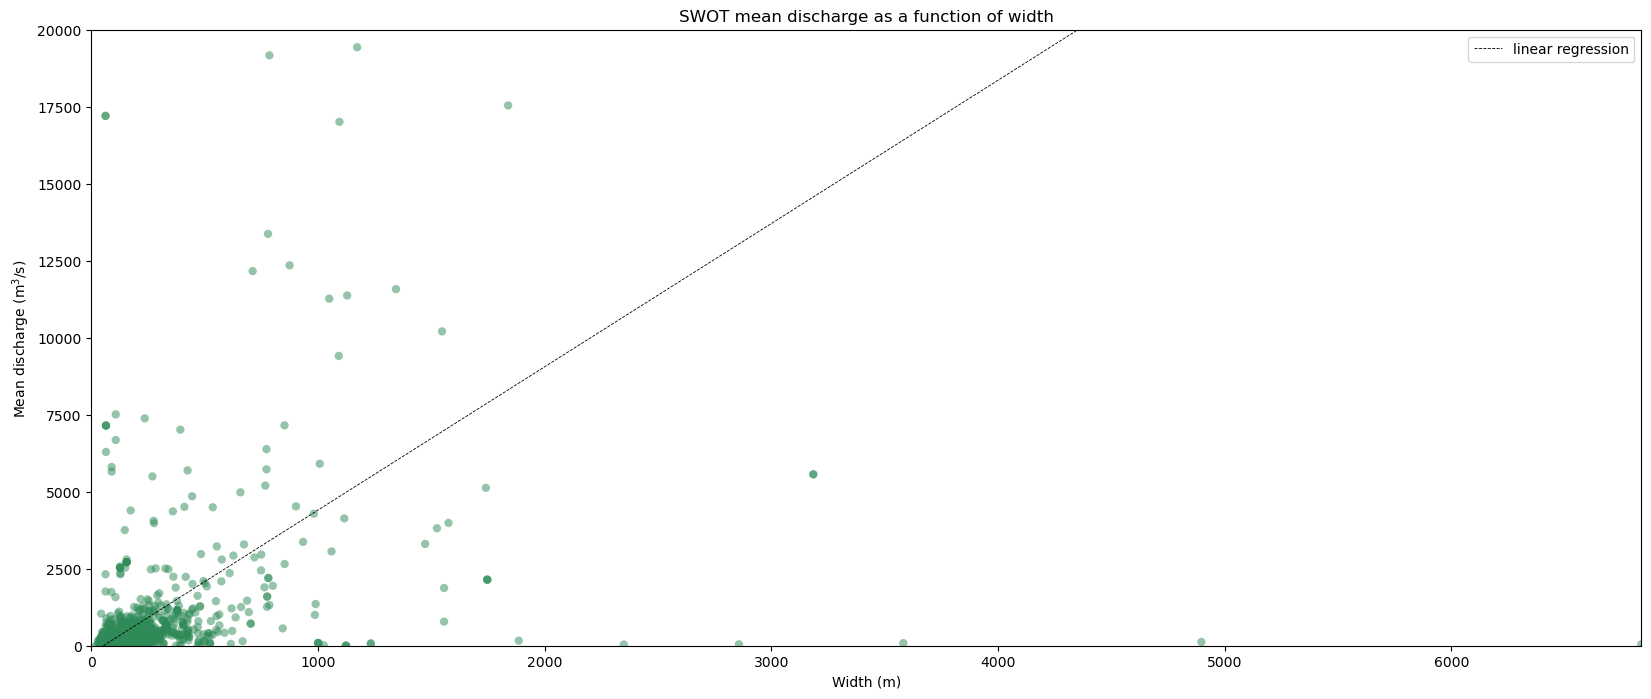

In [56]:
# Discharge
q_s = q_ol_s.mean(dim="time")

# Scatter plot
plt.figure(figsize=(20, 8))
plt.scatter(w_ol_swr, q_s, c='seagreen', alpha=0.5, edgecolors='none')

# Linear regression
ss, bb = np.polyfit(w_ol_swr, q_s, deg=1)
plt.axline(xy1=(0, bb), slope=ss, label=f'linear regression', color='k', linestyle='--', linewidth = 0.6)

# Titles
plt.ylim((0,20000))
plt.xlim((0,np.nanmax(w_ol_swr)))
plt.title("SWOT mean discharge as a function of width") 
plt.legend()
plt.xlabel(r'Width (m)')
plt.ylabel(r'Mean discharge (m$^3$/s)')

# Save
fig_name = f'dschg_vs_w.png'
plt.savefig(f'/obs/ecastonguay/scripts/figures/{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()

### 16. a) Scatter of correlation vs. width

/tmp/ipykernel_33577/117872832.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Figure saved in /obs/ecastonguay/scripts/figures


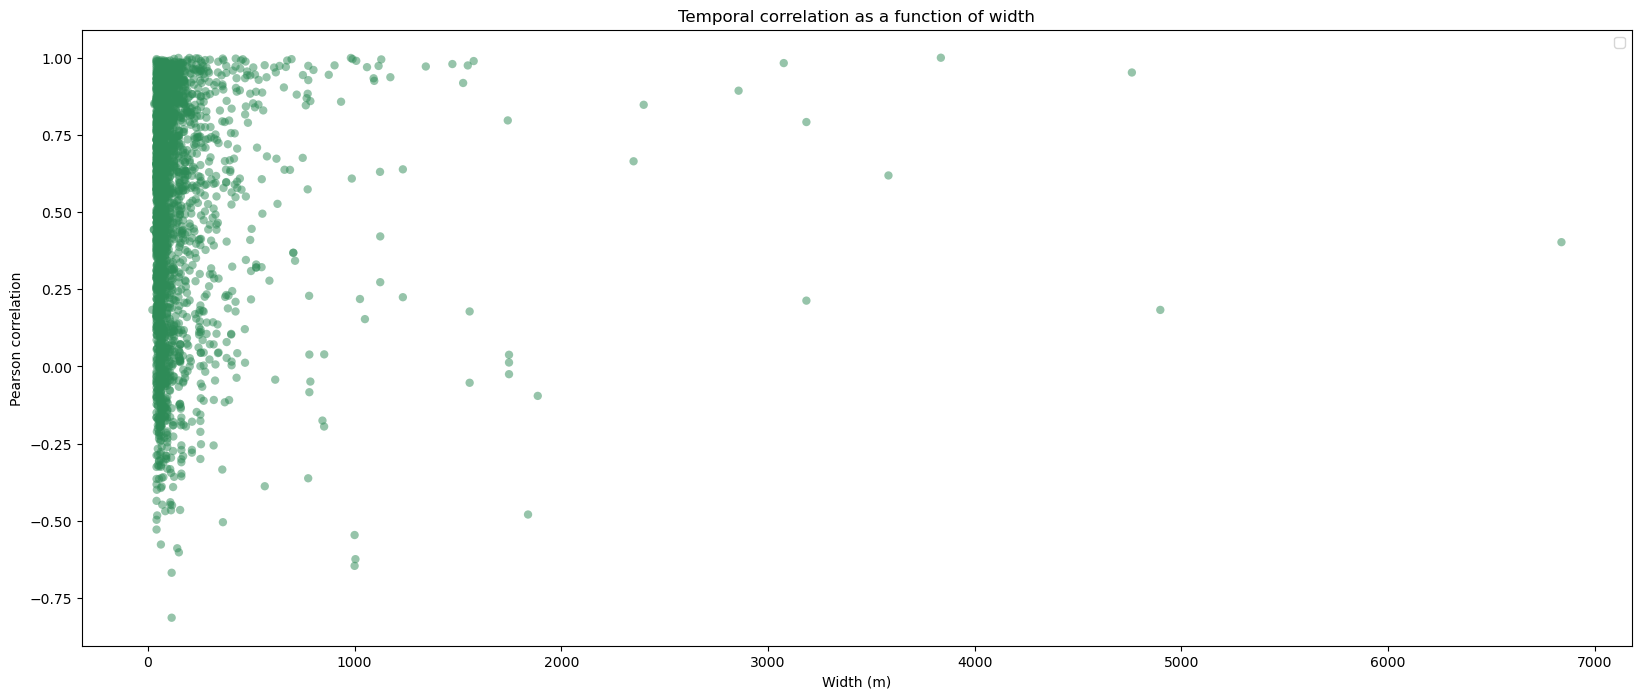

In [57]:
# Correlation
corr = xr.corr(q_ol_s, q_ol_g, dim='time') # [tested]

# Width
# w_ol_swr

# Scatter plot
plt.figure(figsize=(20, 8))
plt.scatter(w_ol_swr, corr, c='seagreen', alpha=0.5, edgecolors='none')

"""# Linear regression
ss, bb = np.polyfit(w_ol_swr, corr, deg=1)
plt.axline(xy1=(0, bb), slope=ss, label=f'linear regression', color='k', linestyle='--', linewidth = 0.6)"""

# Titles
"""plt.ylim((0,20000))
plt.xlim((0,np.nanmax(w_ol_swr)))"""
plt.title("Temporal correlation as a function of width") 
plt.legend()
plt.xlabel(r'Width (m)')
plt.ylabel(r'Pearson correlation')

# Save
fig_name = f'corr_vs_w.png'
plt.savefig(f'/obs/ecastonguay/scripts/figures/{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()


### 16. b) Pdf of corr vs. width

Figure saved in /obs/ecastonguay/scripts/figures


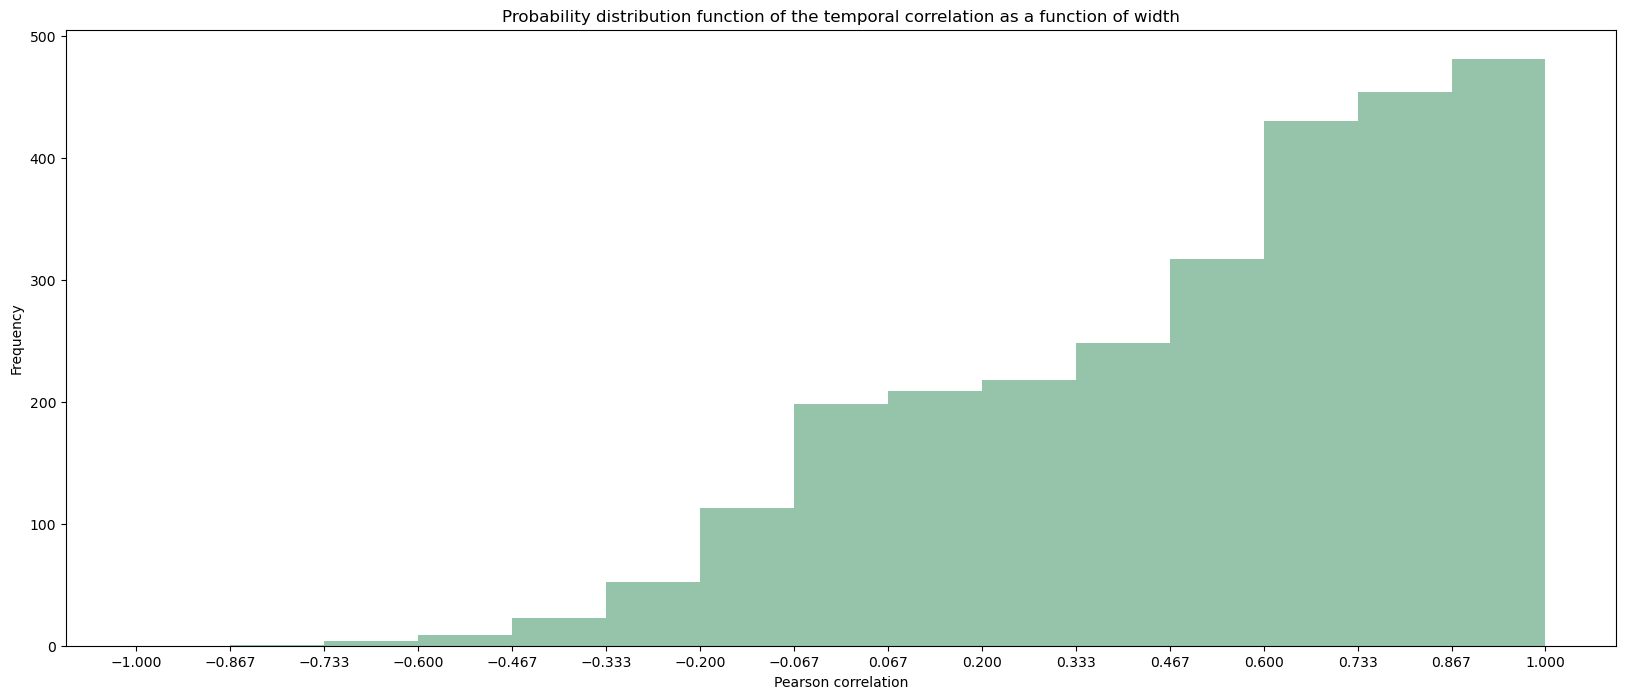

In [58]:
# Correlation
corr = xr.corr(q_ol_s, q_ol_g, dim='time') # [tested]

# Clipping the very high values (including infinites) to a defined maximum
max = 1
min = -1
n_bins = 10
step = (max-min)/n_bins
"""clip_dist = np.clip(dist_nn,min,max)"""

# Plot
plt.figure(figsize=(20, 8))
my_bins = np.linspace(-1, 1, 16)
plt.hist(corr, bins=my_bins, color = 'seagreen', alpha=0.5)
plt.title(f"Probability distribution function of the temporal correlation as a function of width") 
#plt.ylim((0,1750))
plt.xticks(my_bins)
plt.xlabel('Pearson correlation') 
plt.ylabel('Frequency')

# Save
fig_name = f'pdf_corr.png' # SELECT file name
plt.savefig(f'/obs/ecastonguay/scripts/figures/{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures")
plt.show()


### 16. c) 10 best pearson corr. coef.

In [26]:
# Correlations
corr = xr.corr(q_ol_s, q_ol_g, dim='time') # [tested]
corr2 = np.where(np.isnan(corr), -np.inf, corr)
assert corr2.shape == id_ol_g.shape == corr.shape

# Ids of the n best
n_best = 10
print("-> Stations having the best pearson coeff. correlation (worst to best):")
ind_best = np.argpartition(corr2, -n_best)[-n_best:] 
ind_best_sorted = ind_best[np.argsort(corr2[ind_best])] # argpartition does not garantee to sort so we use argsort. sort goes from smallest to biggest value

# List of the 10 best
pearson_10_best = []
pearson_10_best.append(id_ol_g[ind_best_sorted])
print(pearson_10_best)

# Print
for b in range(len(ind_best_sorted)):
    print(f"Station id: {id_ol_g[ind_best_sorted][b]}. Pearson coeff. value: {corr2[ind_best_sorted][b]}")

# Median of the distribution
median_da = corr.median(skipna=True)
median_id_g = id_ol_g[corr==median_da][0]
print("-> Median value")
print(f"Station id: {median_id_g}. Pearson coeff. value: {median_da.values}")

## Results for n best:
# [4149122, 3634200, 3649618, 3634320, 6335060, 6645020, 3618090, 3666050, 2591800, 3627001]
## Results for median: 
# 5405070

"""for i in range(n_best):
    ind_max = np.nanargmax(corr_dlt)
    print(f"Station id: {station_id_dlt[ind_max]}. Pearson coeff. value: {corr_dlt[ind_max]}")
    # retain station ids
    id_pearson_g.append(station_id_dlt[ind_max])
    # delete
    corr_dlt = np.delete(corr_dlt,ind_max)
    station_id_dlt = np.delete(station_id_dlt,ind_max)

print(id_pearson_g)


n_nans = np.isnan(corr).sum() # using count of NaNs to offset and thus compute indices and extract values; https://stackoverflow.com/questions/56377996/using-numpy-argpartition-ignoring-nans
ind_best = np.argpartition(corr, -n_best-n_nans)[-n_best-n_nans:-n_nans] 
ind_best_sorted = ind_best[np.argsort(corr[ind_best])] # argpartition does not garantee to sort so we use argsort. sort goes from smallest to biggest value
# Print
for b in range(len(ind_best_sorted)):
    print(f"Station id: {id_ol_g[ind_best_sorted][b]}. Pearson coeff. value: {corr[ind_best_sorted][b]}")
"""

-> Stations having the best pearson coeff. correlation (worst to best):
[array([4149122, 3634200, 3649618, 3634320, 6335060, 6645020, 3618090,
       3666050, 2591800, 3627001])]
Station id: 4149122. Pearson coeff. value: 0.994941805671489
Station id: 3634200. Pearson coeff. value: 0.9957147700973549
Station id: 3649618. Pearson coeff. value: 0.9965540810421529
Station id: 3634320. Pearson coeff. value: 0.9965856461459977
Station id: 6335060. Pearson coeff. value: 0.996722528855634
Station id: 6645020. Pearson coeff. value: 0.997777119906461
Station id: 3618090. Pearson coeff. value: 0.9986070251451877
Station id: 3666050. Pearson coeff. value: 0.9987345496329381
Station id: 2591800. Pearson coeff. value: 0.9988045189307475
Station id: 3627001. Pearson coeff. value: 0.9993944892032821
-> Median value
Station id: 5405070. Pearson coeff. value: 0.5955524600531169


'for i in range(n_best):\n    ind_max = np.nanargmax(corr_dlt)\n    print(f"Station id: {station_id_dlt[ind_max]}. Pearson coeff. value: {corr_dlt[ind_max]}")\n    # retain station ids\n    id_pearson_g.append(station_id_dlt[ind_max])\n    # delete\n    corr_dlt = np.delete(corr_dlt,ind_max)\n    station_id_dlt = np.delete(station_id_dlt,ind_max)\n\nprint(id_pearson_g)\n\n\nn_nans = np.isnan(corr).sum() # using count of NaNs to offset and thus compute indices and extract values; https://stackoverflow.com/questions/56377996/using-numpy-argpartition-ignoring-nans\nind_best = np.argpartition(corr, -n_best-n_nans)[-n_best-n_nans:-n_nans] \nind_best_sorted = ind_best[np.argsort(corr[ind_best])] # argpartition does not garantee to sort so we use argsort. sort goes from smallest to biggest value\n# Print\nfor b in range(len(ind_best_sorted)):\n    print(f"Station id: {id_ol_g[ind_best_sorted][b]}. Pearson coeff. value: {corr[ind_best_sorted][b]}")\n'

### 17. a) NSE world map

/tmp/ipykernel_33577/1018242149.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  nse_value = 1 - mse/var_obs


Figure saved in /obs/ecastonguay/scripts/figures


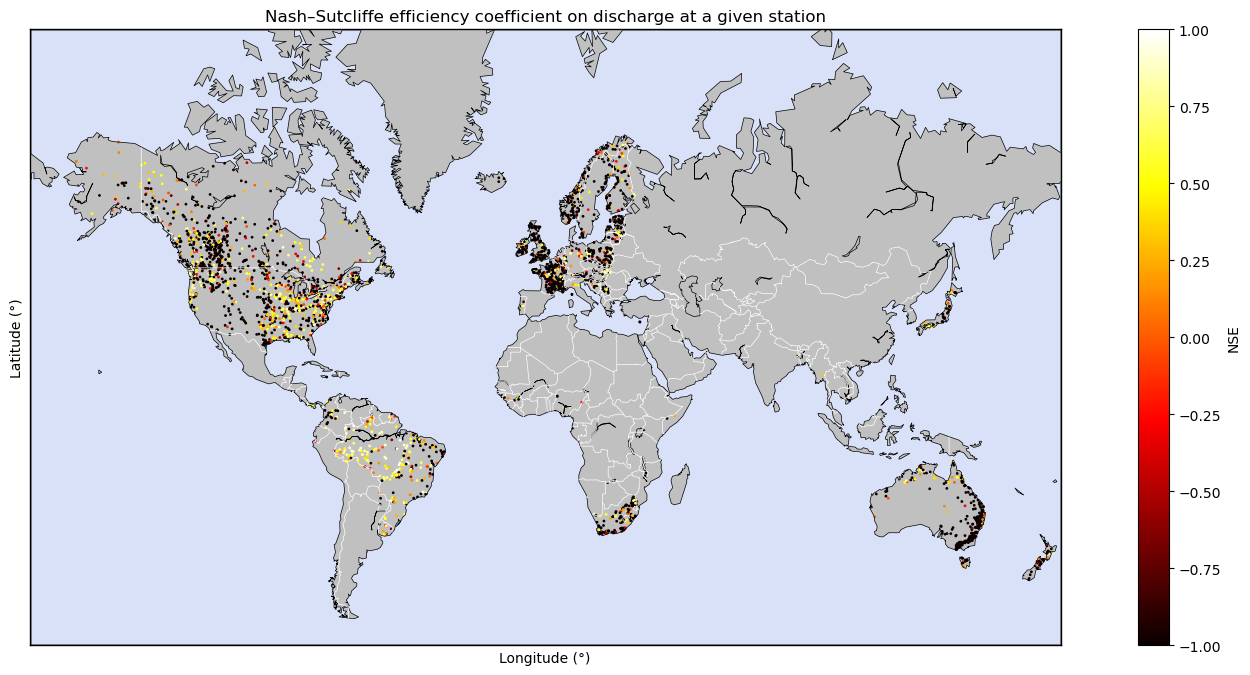

In [ ]:
## NSE definition
def nse(sim, obs): # *** what happens if nans???
    sim = np.asarray(sim, dtype=float)
    obs = np.asarray(obs, dtype=float)

    mask = np.isfinite(sim) & np.isfinite(obs)
    sim = sim[mask]
    obs = obs[mask]

    mse = np.mean((sim - obs)**2) # or : mean_squared_error(obs, sim)
    var_obs = np.std(obs)**2

    nse_value = 1 - mse/var_obs

    return nse_value #, r, alpha, beta

# Compute statistic
assert q_ol_g.shape == q_ol_s.shape

nse_array = np.array([ # q_ol_g.shape: (2776, 766)
    nse(q_ol_s[nn, :], q_ol_g[nn, :])
    for nn in range(q_ol_g.shape[0])
])

if nse_array.shape[0] != q_ol_g.shape[0] != q_ol_s.shape[0]:
    print("Error: Matrixes should have same number of rows. If the kge function deleted rows due to infinite values, adjust (lat,lon) accordingly.")
    
# Determine the 'view' of the world map
plt.figure(figsize=(20, 8))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.5)
map.drawcountries(color='w',linewidth=0.5)
map.drawmapboundary(fill_color=ocean_color) # ocean color
map.fillcontinents(color='silver', lake_color='silver')
#map.fillcontinents(color='black', lake_color='black')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(x_ol_s, y_ol_s)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=nse_array, cmap='hot', marker='o', alpha=1, s=1, vmin=-1,vmax=1) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label='NSE')
plt.title("Nash–Sutcliffe efficiency coefficient on discharge at a given station") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'nse_world.png'
plt.savefig(f'/obs/ecastonguay/scripts/figures/{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()

### 17. b) 10 best NSE

In [ ]:
# NSE
nse2_array = np.where(np.isnan(nse_array), -np.inf, nse_array)

# Ids of the n best
n_best = 10
print("-> Stations having the best NSE (worst to best):")
ind_best = np.argpartition(nse2_array, -n_best)[-n_best:] 
ind_best_sorted = ind_best[np.argsort(nse2_array[ind_best])] # argpartition does not garantee to sort so we use argsort. sort goes from smallest to biggest value

# List of the 10 best
assert id_ol_g.shape == nse2_array.shape
nse_10_best = []
nse_10_best.append(id_ol_g[ind_best_sorted])
print(nse_10_best)

# Print
for b in range(len(ind_best_sorted)):
    print(f"Station id: {id_ol_g[ind_best_sorted][b]}. NSE value: {nse2_array[ind_best_sorted][b]}")

# Median of the distribution
median_da = np.nanmedian(nse_array) # using nse_array with nan values, not nse2_array 
median_index = (np.abs(nse_array - median_da)).argmin()
median_id_g = id_ol_g[median_index]
print("-> Median value")
print(f"Station id: {median_id_g}. NSE value: {median_da}")

## Results for n best:
# [3633121, 4147720, 3635402, 3631500, 3649618, 3649409, 6335060, 3649424, 3649619, 3618090]
## Results for median: 
# 6335030

-> Stations having the best NSE (worst to best):
[array([3633121, 4147720, 3635402, 3631500, 3649618, 3649409, 6335060,
       3649424, 3649619, 3618090])]
Station id: 3633121. NSE value: 0.9504525407063982
Station id: 4147720. NSE value: 0.9519344810373574
Station id: 3635402. NSE value: 0.9552488298723832
Station id: 3631500. NSE value: 0.9557153104345254
Station id: 3649618. NSE value: 0.9627231512079996
Station id: 3649409. NSE value: 0.9695256286808766
Station id: 6335060. NSE value: 0.9700913229110516
Station id: 3649424. NSE value: 0.9731039296236789
Station id: 3649619. NSE value: 0.9749201471800608
Station id: 3618090. NSE value: 0.983097346677735
-> Median value
Station id: 6335030. NSE value: -11.108490753845214


### Top 10 for NSE, KGE, Pearson

In [ ]:
# Looking for the highest scores

nse_10_best
kge_10_best
pearson_10_best